# Assignment #4 — Environmental Sound Classification (Enhanced)
**Alexandria University — Faculty of Engineering — Computer & Systems Engineering**  
**Course:** CSE Pattern Recognition  
**Due:** Wed, Jun 3, 2026

---

## Overview

This notebook classifies urban environmental sounds from the **UrbanSound8K** dataset into 10 categories. It builds on the baseline GRU approach and adds several targeted improvements to push accuracy well above the 65% baseline.

### Key improvements over the baseline
| Area | Baseline | This notebook |
|------|----------|---------------|
| Features | 123-dim (Mel+MFCC+RMS+Chroma+Contrast) | 179-dim (adds ΔMFCCs, MFCC-Δ², Spectral Rolloff, ZCR) |
| Global norm | Per-sample z-score only | Global mean/std pre-computed on training set |
| GRU model | Bidirectional GRU + single attention | Bidirectional GRU + **multi-head** attention + residual projection |
| CNN-GRU | Simple 2-layer CNN | Deep residual CNN (3 blocks, SE attention) + GRU |
| Loss | CrossEntropy | **Label-smoothed** CrossEntropy (ε=0.1) |
| Augmentation | 4 basic augmentations | + **Mixup** + stronger SpecAugment |
| Scheduler | Cosine (no warmup tuning) | Cosine with linear warmup + **ReduceLROnPlateau** fallback |
| Optimizer | AdamW (wd=1e-3) | AdamW (wd=5e-4, tuned) |
| Dropout | 0.5 throughout | 0.3 (tuned to reduce over-aggressive regularisation) |
| Epochs | 50 max | **100** max (patience=15) |

### Dataset splits (unchanged — as per assignment spec)
| Split | Folds | Clips |
|-------|-------|-------|
| Train | 1–6   | ~5 435 |
| Val   | 7–8   | ~1 644 |
| Test  | 9–10  | ~1 653 |

## 0 — Dependencies

In [ ]:
# ── Install once ────────────────────────────────────────────────────────────
# Uncomment the line below if you haven't installed the packages yet.
# !pip install librosa torch torchvision torchaudio scikit-learn matplotlib seaborn pandas tqdm ipywidgets gammatone
import sys, platform

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    # Only runs on Colab — installs CUDA torch
    import subprocess
    subprocess.run(["pip", "uninstall", "-y", "torch", "torchvision", "torchaudio"])
    subprocess.run(["pip", "install", "torch", "torchvision", "torchaudio",
                    "--index-url", "https://download.pytorch.org/whl/cu121"])
else:
    print("Local machine detected — skipping torch reinstall.")
    print("Make sure torch is installed via: pip install torch torchvision torchaudio")
!wget -O /content/urbansound8k.tar.gz "https://goo.gl/8hY5ER"
!pip uninstall -y torch torchvision torchaudio
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip install -q librosa ipywidgets
!pip install gammatone
print("All dependencies assumed installed. Re-run cell above if import errors appear.")

--2026-05-30 17:14:31--  https://goo.gl/8hY5ER
Resolving goo.gl (goo.gl)... 142.251.2.138, 142.251.2.113, 142.251.2.100, ...
Connecting to goo.gl (goo.gl)|142.251.2.138|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://zenodo.org/record/1203745/files/UrbanSound8K.tar.gz [following]
--2026-05-30 17:14:31--  https://zenodo.org/record/1203745/files/UrbanSound8K.tar.gz
Resolving zenodo.org (zenodo.org)... 137.138.153.219, 188.184.98.114, 188.185.43.153, ...
Connecting to zenodo.org (zenodo.org)|137.138.153.219|:443... connected.
HTTP request sent, awaiting response... 301 MOVED PERMANENTLY
Location: /records/1203745/files/UrbanSound8K.tar.gz [following]
--2026-05-30 17:14:32--  https://zenodo.org/records/1203745/files/UrbanSound8K.tar.gz
Reusing existing connection to zenodo.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 6023741708 (5.6G) [application/octet-stream]
Saving to: ‘/content/urbansound8k.tar.gz’

/content/urbansound 100%[====

In [4]:
import tarfile

print("Extracting UrbanSound8K.tar.gz...")
with tarfile.open('/content/urbansound8k.tar.gz', 'r:gz') as tar:
    tar.extractall('/content/')
print("Extraction complete.")

Extracting UrbanSound8K.tar.gz...
Extraction complete.


In [5]:
!ls -F /content/UrbanSound8K/

audio/	FREESOUNDCREDITS.txt  metadata/  UrbanSound8K_README.txt*


## 1 — Imports & Global Configuration

In [ ]:
# ── Standard library ──────────────────────────────────────────────────────────
import os, sys, time, json, random, warnings
from pathlib import Path

# ── Scientific stack ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
from scipy.fftpack import dct as _scipy_dct
import gammatone.fftweight as _gtfw        # Gammatone filterbank (GTFB/GFCC)
from tqdm.auto import tqdm

# ── PyTorch ───────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# ── Sklearn metrics ───────────────────────────────────────────────────────────
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

warnings.filterwarnings('ignore')

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True

# ── Device ────────────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

# ── Paths (adjust DATA_ROOT to your local setup) ─────────────────────────────
DATA_ROOT = Path('/content/UrbanSound8K')      # Colab default; change if local
AUDIO_DIR = DATA_ROOT / 'audio'
META_FILE = DATA_ROOT / 'metadata' / 'UrbanSound8K.csv'
CACHE_DIR = Path('feature_cache_v3')           # v3 — includes GFCC + multi-scale Mel
OUTPUT_DIR = Path('outputs_v3')
CACHE_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

# ── Dataset constants ─────────────────────────────────────────────────────────
TRAIN_FOLDS = [1, 2, 3, 4, 5, 6]
VAL_FOLDS   = [7, 8]
TEST_FOLDS  = [9, 10]
NUM_CLASSES = 10
CLASS_NAMES = ['air_conditioner', 'car_horn', 'children_playing', 'dog_bark',
               'drilling', 'engine_idling', 'gun_shot', 'jackhammer',
               'siren', 'street_music']

# ── Audio / feature constants ─────────────────────────────────────────────────
SR          = 22050
DURATION    = 4.0
N_SAMPLES   = int(SR * DURATION)   # 88 200
N_FFT       = 1024
HOP_LENGTH  = 512
N_MELS      = 128     # ↑ from 64 — more frequency resolution
N_MFCC      = 40
N_CHROMA    = 12
N_CONTRAST  = 6

# ── Extra feature constants ──────────────────────────────────────────────────
N_GTFB      = 64     # Gammatone filterbank channels
N_GFCC      = 40     # GFCCs to keep (same as MFCC count)
# Multi-scale Log-Mel: finer + coarser resolution alongside the standard hop
HOP_SHORT   = 256    # finer temporal resolution  (≈11.6 ms/frame)
HOP_LONG    = 1024   # coarser temporal resolution (≈46.4 ms/frame)

# Total feature dimension:
# 128 (Mel) + 40 (MFCC) + 40 (Δ-MFCC) + 40 (ΔΔ-MFCC) + 1 (RMS)
# + 12 (Chroma) + 6 (Contrast) + 1 (ZCR) + 1 (Rolloff) = 269  ← existing
# + 40 (GFCC) = 309                                              ← new: GTFB/GFCC
# + 128 (Mel-short, db) + 128 (Mel-long, db) = 565              ← new: multi-scale Mel
FEATURE_DIM = (N_MELS + N_MFCC + N_MFCC + N_MFCC + 1
               + N_CHROMA + N_CONTRAST + 1 + 1   # 269 existing
               + N_GFCC                           # 40  GFCC
               + N_MELS + N_MELS)                 # 256 multi-scale Mel (short + long)
print(f"Feature dimension: {FEATURE_DIM}  (existing 269 + 40 GFCC + 256 multi-scale Mel)")

Device: cuda
Feature dimension: 565  (existing 269 + 40 GFCC + 256 multi-scale Mel)


## 2 — Load Metadata

In [8]:
meta = pd.read_csv(META_FILE)
print(f"Total clips: {len(meta)}")
print(f"Columns: {list(meta.columns)}")
print(f"Class distribution:\n{meta['class'].value_counts()}")
print(f"\nFold distribution:\n{meta['fold'].value_counts().sort_index()}")

Total clips: 8732
Columns: ['slice_file_name', 'fsID', 'start', 'end', 'salience', 'fold', 'classID', 'class']
Class distribution:
class
dog_bark            1000
children_playing    1000
air_conditioner     1000
street_music        1000
jackhammer          1000
engine_idling       1000
drilling            1000
siren                929
car_horn             429
gun_shot             374
Name: count, dtype: int64

Fold distribution:
fold
1     873
2     888
3     925
4     990
5     936
6     823
7     838
8     806
9     816
10    837
Name: count, dtype: int64


In [8]:
!ls -F /content/UrbanSound8K/metadata/

UrbanSound8K.csv


## 3 — Audio Loading & Visualisation

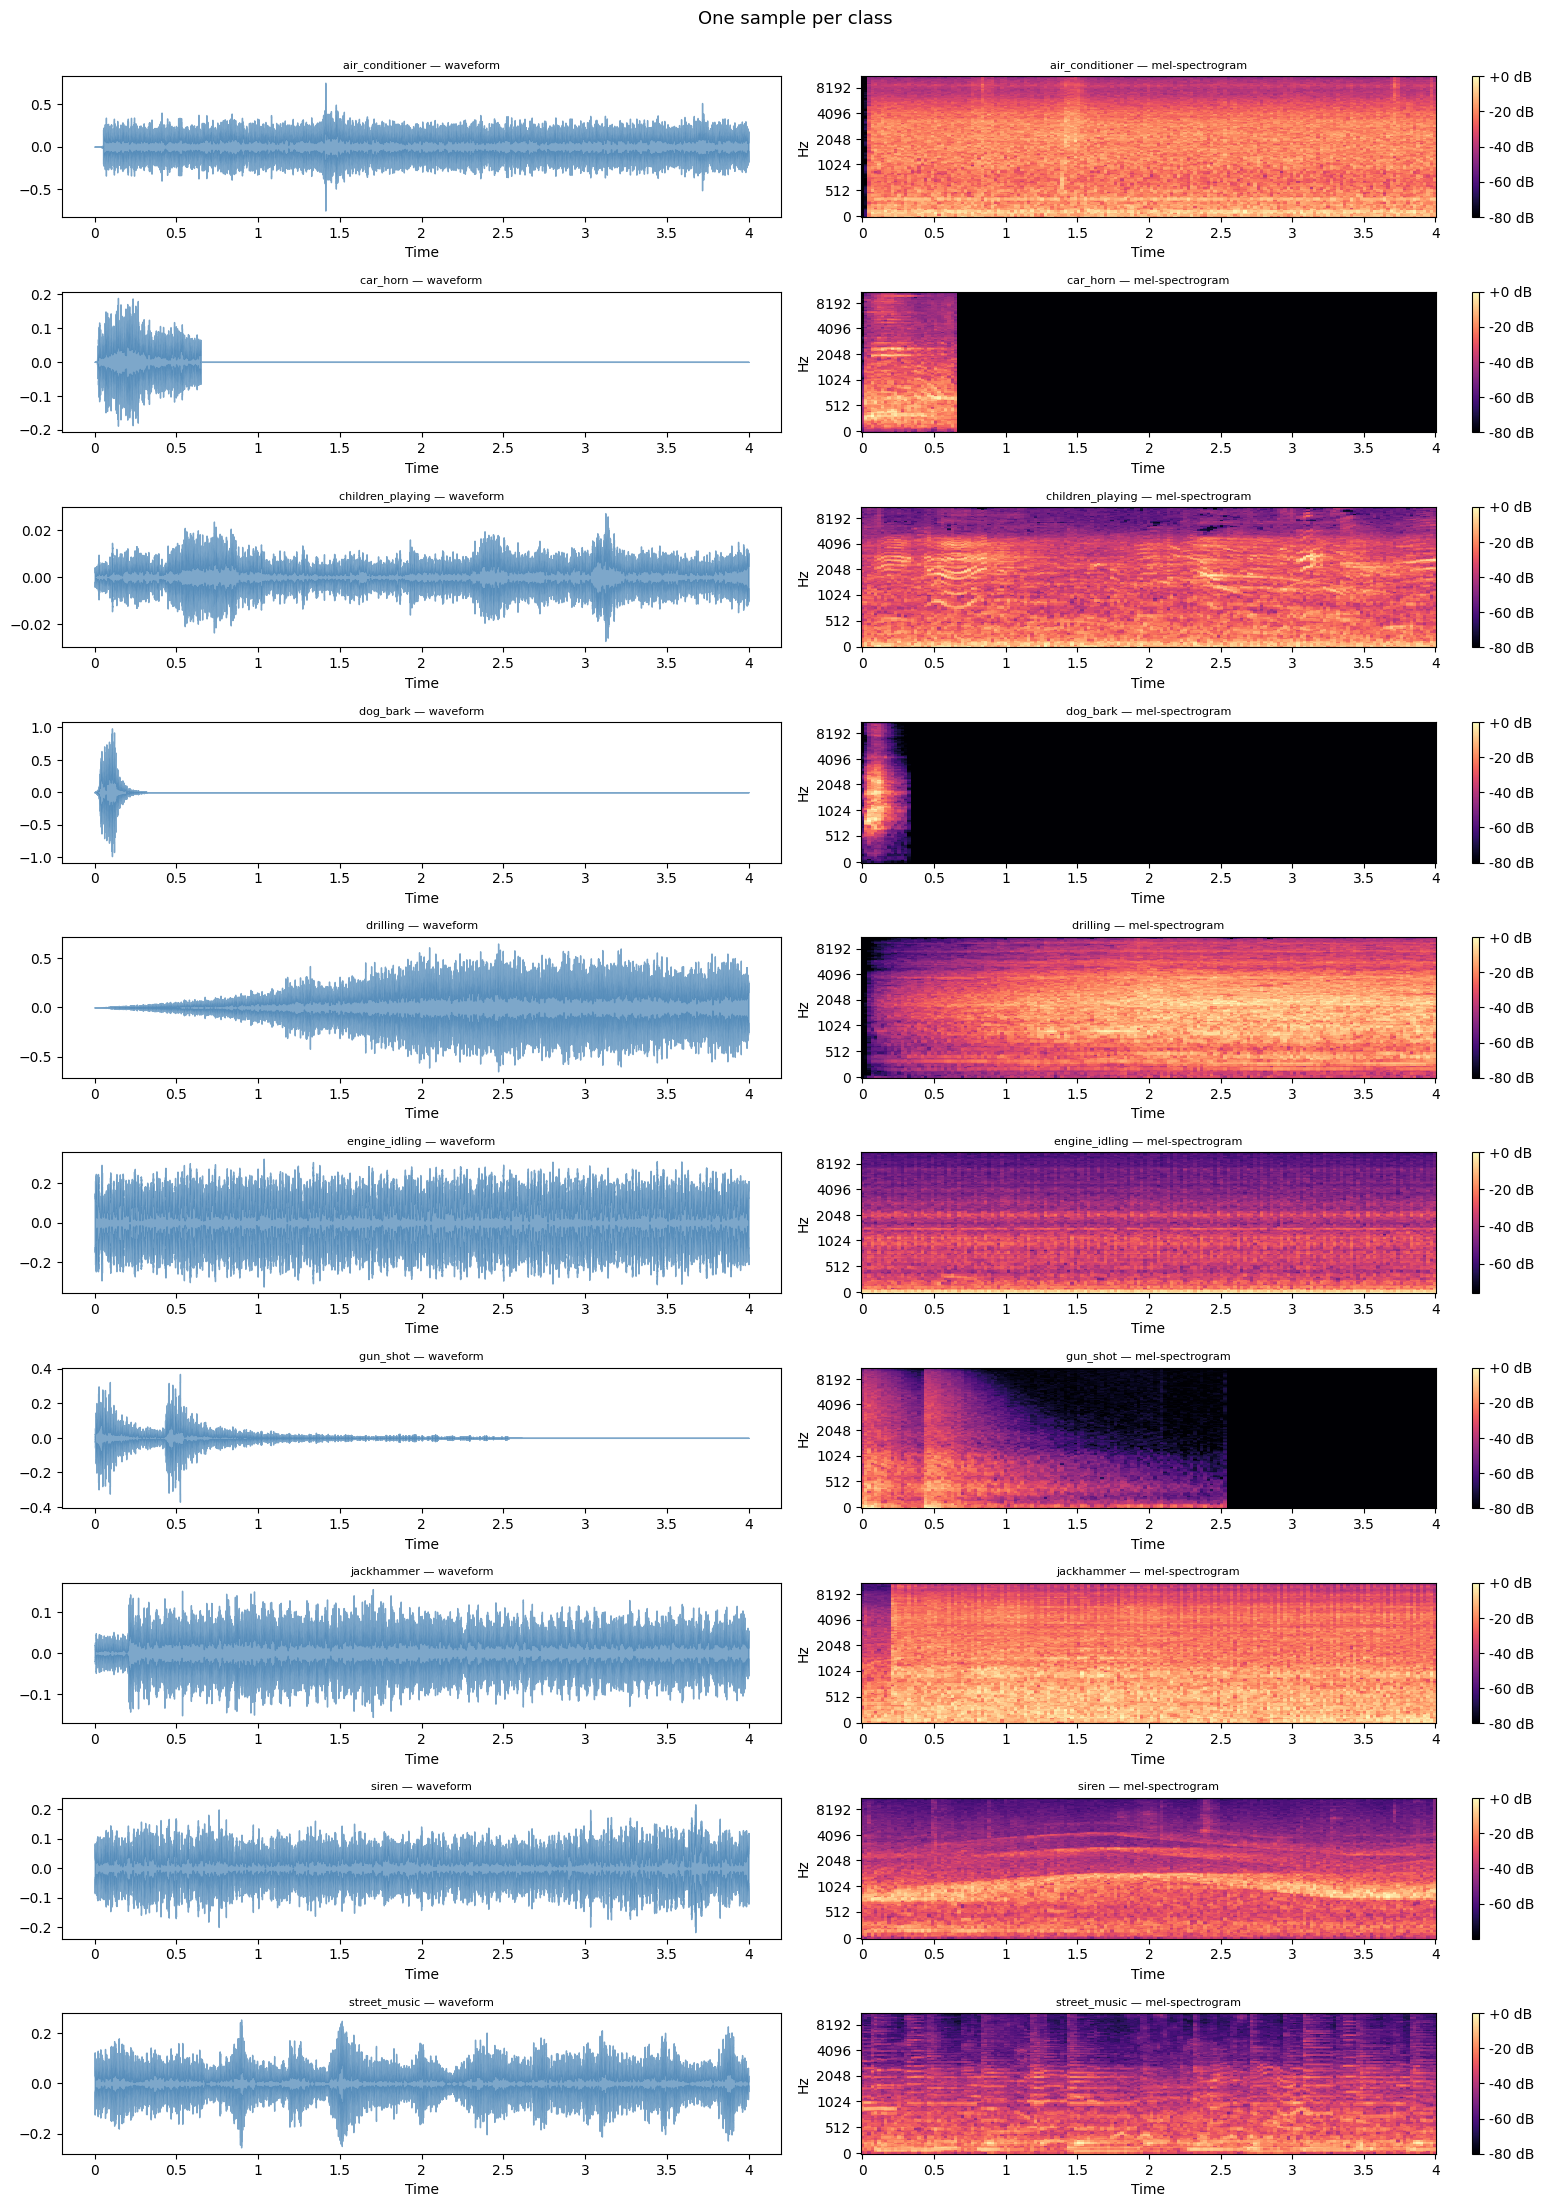

Saved → outputs_v2/class_gallery.png


In [9]:
def load_audio(filepath: Path, sr: int = SR, duration: float = DURATION) -> np.ndarray:
    """
    Load an audio file, resample to `sr`, and pad/trim to exactly `duration` seconds.
    Returns a mono float32 array of shape (N_SAMPLES,).
    """
    y, _ = librosa.load(filepath, sr=sr, mono=True, duration=duration)
    target = int(sr * duration)
    if len(y) < target:
        y = np.pad(y, (0, target - len(y)), mode='constant')
    else:
        y = y[:target]
    return y.astype(np.float32)


def plot_sample(filepath: Path, title: str = "") -> None:
    """Plot waveform and mel-spectrogram side by side for a single clip."""
    y = load_audio(filepath)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3))

    # Waveform
    librosa.display.waveshow(y, sr=SR, ax=ax1, color='steelblue', alpha=0.7)
    ax1.set_title(f'Waveform — {title}')

    # Mel-spectrogram
    S   = librosa.feature.melspectrogram(y=y, sr=SR, n_mels=N_MELS,
                                          n_fft=N_FFT, hop_length=HOP_LENGTH)
    Sdb = librosa.power_to_db(S, ref=np.max)
    img = librosa.display.specshow(Sdb, sr=SR, hop_length=HOP_LENGTH,
                                    x_axis='time', y_axis='mel', ax=ax2)
    ax2.set_title(f'Mel-spectrogram — {title}')
    fig.colorbar(img, ax=ax2, format='%+2.0f dB')
    plt.tight_layout()
    plt.show()


# ── Gallery: one sample per class ─────────────────────────────────────────────
fig, axes = plt.subplots(NUM_CLASSES, 2, figsize=(16, NUM_CLASSES * 2.2))

for idx, cls in enumerate(CLASS_NAMES):
    row = meta[meta['class'] == cls].iloc[0]
    fp  = AUDIO_DIR / f"fold{row['fold']}" / row['slice_file_name']
    y   = load_audio(fp)

    librosa.display.waveshow(y, sr=SR, ax=axes[idx, 0], color='steelblue', alpha=0.7)
    axes[idx, 0].set_title(f'{cls} — waveform', fontsize=8)

    S   = librosa.feature.melspectrogram(y=y, sr=SR, n_mels=N_MELS,
                                          n_fft=N_FFT, hop_length=HOP_LENGTH)
    Sdb = librosa.power_to_db(S, ref=np.max)
    img = librosa.display.specshow(Sdb, sr=SR, hop_length=HOP_LENGTH,
                                    x_axis='time', y_axis='mel',
                                    ax=axes[idx, 1])
    axes[idx, 1].set_title(f'{cls} — mel-spectrogram', fontsize=8)
    fig.colorbar(img, ax=axes[idx, 1], format='%+2.0f dB')

plt.suptitle('One sample per class', fontsize=13, y=1.001)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'class_gallery.png', dpi=110, bbox_inches='tight')
plt.show()
print('Saved → outputs_v2/class_gallery.png')

## 4 — Enhanced Feature Extraction

We significantly expand the feature set compared to the baseline.

| Feature | Dim | What it captures |
|---------|-----|------------------|
| Mel-spectrogram (128 bins) | 128 | Fine-grained timbral texture (2× baseline resolution) |
| MFCCs (40 coeffs) | 40 | Spectral envelope / vocal-tract shape |
| Δ-MFCCs | 40 | Rate of change of MFCCs — temporal dynamics |
| ΔΔ-MFCCs | 40 | Acceleration of MFCCs — onset/offset events |
| RMS Energy | 1 | Overall loudness dynamics |
| Chroma STFT | 12 | Pitch-class content |
| Spectral Contrast | 6 | Peak vs. valley in 6 sub-bands |
| Zero-Crossing Rate | 1 | Noisiness / consonant/vowel distinction |
| Spectral Rolloff | 1 | Frequency below which 85% of energy lies |
| **GFCCs — Gammatone Freq. Cepstral Coeffs** | **40** | **Auditory-model filterbank cepstrum; captures perceptual timbre missed by linear Mel** |
| **Multi-scale Mel (short hop=256)** | **128** | **Fine temporal resolution — sharp transients (gun-shot, car-horn)** |
| **Multi-scale Mel (long hop=1024)** | **128** | **Coarse temporal resolution — sustained textures (engine-idle, A/C)** |
| **Total** | **565** | — |

### Why Δ and ΔΔ MFCCs matter
Delta features capture the rate of spectral change over time. For sounds like car horns (sharp onset) vs. engine idling (steady-state), the delta features carry discriminative information the static MFCCs miss.  
Delta-delta features encode the curvature / acceleration of spectral dynamics.

### Why GFCCs (Gammatone Filterbank Cepstral Coefficients)
The standard Mel filterbank uses linearly-spaced triangular filters below 1 kHz and logarithmically-spaced ones above — a psychoacoustic approximation. The **Gammatone filterbank** models the basilar membrane's response more faithfully using the ERB (Equivalent Rectangular Bandwidth) scale and gammatone-shaped impulse responses. GFCCs are then the DCT of the log-gammatone filterbank energies — analogous to MFCCs but computed on a more auditorily-accurate frequency axis. They have proven particularly discriminative for environmental sounds because perceptual frequency-resolution differences matter for textures like engine noise vs. street music.

### Why Multi-scale Log-Mel (multiple hop lengths)
Using a single hop length (`HOP_LENGTH=512`) gives one temporal resolution (~23 ms/frame). A **short hop** (256 → ~11.6 ms/frame) captures transient events like gun-shots and car-horns that unfold over tens of milliseconds; a **long hop** (1024 → ~46.4 ms/frame) captures slowly-evolving textures like air conditioners and engine-idling. Concatenating all three resolutions lets the model jointly attend to fine and coarse temporal structure without changing the architecture — it simply sees more context per frame.

In [10]:
def extract_features(y: np.ndarray, sr: int = SR) -> np.ndarray:
    """
    Extract and concatenate enhanced acoustic features.

    Includes the original 9 feature groups (269 dims) plus:
      - GFCCs from the Gammatone filterbank (40 dims)
      - Multi-scale Log-Mel: short-hop (128) + long-hop (128) = 256 dims
    Total: 565 dims per frame.

    Returns
    -------
    features : np.ndarray, shape (T, FEATURE_DIM)
        T = ceil(N_SAMPLES / HOP_LENGTH)  [reference frame count, hop=512]
    """
    # 1. Mel-spectrogram  (128 × T)
    mel    = librosa.feature.melspectrogram(
        y=y, sr=sr, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH)
    mel_db = librosa.power_to_db(mel, ref=np.max)

    # 2. MFCCs  (40 × T)
    mfcc   = librosa.feature.mfcc(
        y=y, sr=sr, n_mfcc=N_MFCC, n_fft=N_FFT, hop_length=HOP_LENGTH)

    # 3. Delta MFCCs  (40 × T)
    d_mfcc  = librosa.feature.delta(mfcc, order=1)

    # 4. Delta-Delta MFCCs  (40 × T)
    dd_mfcc = librosa.feature.delta(mfcc, order=2)

    # 5. RMS Energy  (1 × T)
    rms    = librosa.feature.rms(
        y=y, frame_length=N_FFT, hop_length=HOP_LENGTH)

    # 6. Chroma STFT  (12 × T)
    chroma = librosa.feature.chroma_stft(
        y=y, sr=sr, n_chroma=N_CHROMA, n_fft=N_FFT, hop_length=HOP_LENGTH)

    # 7. Spectral Contrast  (6 × T)
    contrast = librosa.feature.spectral_contrast(
        y=y, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH)[:N_CONTRAST, :]

    # 8. Zero-Crossing Rate  (1 × T)
    zcr    = librosa.feature.zero_crossing_rate(
        y=y, frame_length=N_FFT, hop_length=HOP_LENGTH)

    # 9. Spectral Rolloff  (1 × T)
    rolloff = librosa.feature.spectral_rolloff(
        y=y, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH, roll_percent=0.85)

    # ── NEW: Gammatone Filterbank / GFCCs (40 × T) ──────────────────────────
    # Compute gammatone spectrogram using the same window & hop as above
    _gt_spec = _gtfw.fft_gtgram(
        y.astype(np.float64), sr,
        N_FFT / sr,        # window_time  (same as N_FFT=1024 frames)
        HOP_LENGTH / sr,   # hop_time
        N_GTFB, 50.0       # number of channels, lowest centre freq (Hz)
    )  # (N_GTFB, T_gt) — power values, float64
    _gt_log = np.log(_gt_spec + 1e-8)             # (N_GTFB, T_gt) — log compression
    gfcc = _scipy_dct(
        _gt_log, type=2, axis=0, norm='ortho'
    )[:N_GFCC, :]                                  # (N_GFCC, T_gt)  DCT-II cepstrum

    # ── NEW: Multi-scale Log-Mel (short hop + long hop) ─────────────────────
    # Short hop — finer temporal resolution (~11.6 ms/frame, HOP_SHORT=256)
    _mel_s    = librosa.feature.melspectrogram(
        y=y, sr=sr, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_SHORT)
    mel_short = librosa.power_to_db(_mel_s, ref=np.max)    # (128, T_short)

    # Long hop — coarser temporal resolution (~46.4 ms/frame, HOP_LONG=1024)
    _mel_l    = librosa.feature.melspectrogram(
        y=y, sr=sr, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LONG)
    mel_long  = librosa.power_to_db(_mel_l, ref=np.max)    # (128, T_long)

    # ── Align all features to reference T (from standard hop=512) ───────────
    T = mel_db.shape[1]
    def _align(arr):
        if arr.shape[1] > T:  return arr[:, :T]
        if arr.shape[1] < T:  return np.pad(arr, ((0,0),(0, T - arr.shape[1])))
        return arr

    mfcc      = _align(mfcc)
    d_mfcc    = _align(d_mfcc)
    dd_mfcc   = _align(dd_mfcc)
    rms       = _align(rms)
    chroma    = _align(chroma)
    contrast  = _align(contrast)
    zcr       = _align(zcr)
    rolloff   = _align(rolloff)
    gfcc      = _align(gfcc)       # NEW: align GFCC to reference T
    mel_short = _align(mel_short)  # NEW: align short-hop Mel
    mel_long  = _align(mel_long)   # NEW: align long-hop Mel

    # ── Stack  (FEATURE_DIM × T)  →  transpose  (T × FEATURE_DIM) ──────────
    combined = np.vstack([
        mel_db,     # 128  — standard Mel (existing)
        mfcc,       #  40  — MFCCs (existing)
        d_mfcc,     #  40  — Δ-MFCCs (existing)
        dd_mfcc,    #  40  — ΔΔ-MFCCs (existing)
        rms,        #   1  — RMS energy (existing)
        chroma,     #  12  — Chroma (existing)
        contrast,   #   6  — Spectral Contrast (existing)
        zcr,        #   1  — ZCR (existing)
        rolloff,    #   1  — Rolloff (existing)
        gfcc,       #  40  — GFCCs from Gammatone filterbank (NEW)
        mel_short,  # 128  — Short-hop Mel (NEW)
        mel_long,   # 128  — Long-hop Mel  (NEW)
    ])  # (565, T)
    return combined.T.astype(np.float32)   # (T, 565)


# ── Sanity check ─────────────────────────────────────────────────────────────
sample_row = meta.iloc[0]
sample_fp  = AUDIO_DIR / f"fold{sample_row['fold']}" / sample_row['slice_file_name']
sample_y   = load_audio(sample_fp)
sample_ft  = extract_features(sample_y)
print(f"Sample feature shape: {sample_ft.shape}  →  (T × {FEATURE_DIM})")
assert sample_ft.shape[1] == FEATURE_DIM, f"Expected {FEATURE_DIM}, got {sample_ft.shape[1]}"
print("Feature dimension OK ✓")

Sample feature shape: (173, 565)  →  (T × 565)
Feature dimension OK ✓


### 4.1 — Build & Cache Features

In [11]:
def build_feature_cache(meta: pd.DataFrame, audio_dir: Path, cache_dir: Path) -> None:
    """
    For every row in `meta`, compute features if the cache file doesn't exist.
    Stores: cache_dir / f"{fold}_{filename}.npy"
    """
    total = len(meta)
    skipped = errors = 0

    for _, row in tqdm(meta.iterrows(), total=total, desc='Extracting features'):
        key   = f"{row['fold']}_{row['slice_file_name']}.npy"
        cpath = cache_dir / key

        if cpath.exists():
            skipped += 1
            continue

        fp = audio_dir / f"fold{row['fold']}" / row['slice_file_name']
        try:
            y  = load_audio(fp)
            ft = extract_features(y)
            np.save(str(cpath), ft)
        except Exception as e:
            print(f"  ERROR {fp.name}: {e}")
            errors += 1

    print(f"\nDone.  Extracted: {total - skipped - errors}  "
          f"Cached (skipped): {skipped}  Errors: {errors}")


build_feature_cache(meta, AUDIO_DIR, CACHE_DIR)

Extracting features:   0%|          | 0/8732 [00:00<?, ?it/s]


Done.  Extracted: 8732  Cached (skipped): 0  Errors: 0


### 4.2 — Compute Global Normalisation Statistics

A critical improvement over the baseline: instead of normalising each clip independently at runtime (which discards inter-clip scale information), we pre-compute the **global mean and standard deviation** over the entire training set and use those fixed statistics for all splits.  
This makes the model's input distribution consistent and helps generalisation.

In [12]:
GLOBAL_STATS_FILE = CACHE_DIR / 'global_stats.npz'

if GLOBAL_STATS_FILE.exists():
    data       = np.load(str(GLOBAL_STATS_FILE))
    GLOBAL_MU  = data['mu']    # (FEATURE_DIM,)
    GLOBAL_STD = data['std']   # (FEATURE_DIM,)
    print(f"Loaded global stats from cache.")
else:
    print("Computing global normalisation statistics over training set...")
    train_meta = meta[meta['fold'].isin(TRAIN_FOLDS)].reset_index(drop=True)

    # Welford online mean and M2 (numerically stable)
    count   = np.zeros(FEATURE_DIM, dtype=np.float64)
    mean    = np.zeros(FEATURE_DIM, dtype=np.float64)
    M2      = np.zeros(FEATURE_DIM, dtype=np.float64)

    for _, row in tqdm(train_meta.iterrows(), total=len(train_meta)):
        key  = f"{row['fold']}_{row['slice_file_name']}.npy"
        ft   = np.load(str(CACHE_DIR / key)).astype(np.float64)  # (T, F)
        for t in range(ft.shape[0]):
            count  += 1
            delta   = ft[t] - mean
            mean   += delta / count
            M2     += delta * (ft[t] - mean)

    GLOBAL_MU  = mean.astype(np.float32)
    GLOBAL_STD = (np.sqrt(M2 / count) + 1e-8).astype(np.float32)
    np.savez(str(GLOBAL_STATS_FILE), mu=GLOBAL_MU, std=GLOBAL_STD)
    print(f"Global stats saved.")

print(f"Global MU  shape: {GLOBAL_MU.shape}  range: [{GLOBAL_MU.min():.2f}, {GLOBAL_MU.max():.2f}]")
print(f"Global STD shape: {GLOBAL_STD.shape}  range: [{GLOBAL_STD.min():.4f}, {GLOBAL_STD.max():.4f}]")

Computing global normalisation statistics over training set...


  0%|          | 0/5435 [00:00<?, ?it/s]

Global stats saved.
Global MU  shape: (565,)  range: [-340.54, 3548.44]
Global STD shape: (565,)  range: [0.0513, 2339.4319]


## 5 — Dataset & DataLoader

### Augmentation strategy

1. **SpecAugment** — time masking (up to 25 frames) and frequency masking (up to 30 bins), applied independently with probability 0.6 each.
2. **Gaussian noise** — adds minor perturbation to avoid over-fitting to exact feature values.
3. **Random amplitude scaling** — simulates volume variation.
4. **Mixup** — blends two samples and their labels in feature space. This is applied in the training loop rather than the Dataset, so it can operate on entire batches.

In [13]:
# Compute fixed sequence length from a representative sample
MAX_LEN = sample_ft.shape[0]   # ~173 frames for 4-second clip at HOP=512
print(f"MAX_LEN = {MAX_LEN} frames")


class UrbanSoundDataset(Dataset):
    """
    UrbanSound8K dataset loader with optional augmentation.

    Normalisation:
        (ft - GLOBAL_MU) / GLOBAL_STD   —  applied to every sample
    """

    def __init__(self, meta, folds, cache_dir, max_len=MAX_LEN,
                 global_mu=None, global_std=None, augment=False):
        self.cache_dir  = cache_dir
        self.max_len    = max_len
        self.augment    = augment
        self.global_mu  = global_mu   # (F,)
        self.global_std = global_std  # (F,)
        self.records    = meta[meta['fold'].isin(folds)].reset_index(drop=True)

    def __len__(self):
        return len(self.records)

    def _spec_augment(self, ft: np.ndarray) -> np.ndarray:
        """Apply SpecAugment-style masking in time and frequency."""
        ft = ft.copy()
        T, F = ft.shape

        # Time masking — up to 25 frames (≈ 0.6 s)
        if random.random() < 0.6:
            t_w = random.randint(5, 25)
            t_s = random.randint(0, max(0, T - t_w))
            ft[t_s:t_s + t_w, :] = 0.0

        # Frequency masking — up to 30 feature bands
        if random.random() < 0.6:
            f_w = random.randint(5, 30)
            f_s = random.randint(0, max(0, F - f_w))
            ft[:, f_s:f_s + f_w] = 0.0

        # Gaussian noise
        if random.random() < 0.4:
            ft += np.random.normal(0, 0.05, ft.shape).astype(np.float32)

        # Amplitude scaling
        if random.random() < 0.4:
            ft *= random.uniform(0.75, 1.25)

        return ft

    def __getitem__(self, idx):
        row = self.records.iloc[idx]
        key = f"{row['fold']}_{row['slice_file_name']}.npy"
        ft  = np.load(str(self.cache_dir / key))   # (T, F)  float32

        # ── Global normalisation ─────────────────────────────────────────────
        if self.global_mu is not None:
            ft = (ft - self.global_mu[None, :]) / self.global_std[None, :]
        else:
            # Fallback: per-sample z-score
            mu    = ft.mean(axis=0, keepdims=True)
            sigma = ft.std(axis=0, keepdims=True) + 1e-8
            ft    = (ft - mu) / sigma

        # ── Pad / truncate to MAX_LEN ────────────────────────────────────────
        T = ft.shape[0]
        if T < self.max_len:
            ft = np.vstack([ft, np.zeros((self.max_len - T, ft.shape[1]),
                                         dtype=np.float32)])
        else:
            ft = ft[:self.max_len]

        # ── Augmentation (training only) ─────────────────────────────────────
        if self.augment:
            ft = self._spec_augment(ft)

        label = int(row['classID'])
        return (torch.tensor(ft, dtype=torch.float32),
                torch.tensor(label, dtype=torch.long))


def make_loader(meta, folds, batch_size=32, shuffle=True, augment=False):
    ds = UrbanSoundDataset(
        meta, folds, CACHE_DIR,
        global_mu=GLOBAL_MU, global_std=GLOBAL_STD,
        augment=augment
    )
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle,
                      num_workers=0, pin_memory=False)


# ── Quick shape check ────────────────────────────────────────────────────────
tmp = make_loader(meta, TRAIN_FOLDS[:1], batch_size=4, shuffle=False)
xb, yb = next(iter(tmp))
print(f"Batch shapes → X: {xb.shape}  y: {yb.shape}")
del tmp

MAX_LEN = 173 frames
Batch shapes → X: torch.Size([4, 173, 565])  y: torch.Size([4])


## 6 — Model Architectures

### 6.1 — Enhanced GRU Classifier

Improvements over the baseline GRU:
- **Multi-head attention** (4 heads) instead of a single linear attention layer — allows the model to jointly attend to temporal representations from multiple perspectives.
- **Residual projection** from the input to the GRU output — helps gradient flow in deeper networks.
- **BatchNorm** before the final head — stabilises activations after attention pooling.
- **Reduced dropout** (0.3) — the baseline's 0.5 caused under-fitting after fewer epochs; 0.3 lets the model converge further.

In [14]:
class MultiHeadAttentionPool(nn.Module):
    """
    Multi-head attention pooling over the time dimension.

    Each head learns an independent soft weighting over T timesteps.
    The weighted context vectors from all heads are concatenated and projected
    back to `dim`.
    """
    def __init__(self, dim: int, num_heads: int = 4):
        super().__init__()
        assert dim % num_heads == 0
        self.num_heads  = num_heads
        self.head_dim   = dim // num_heads
        # One scalar score per head per timestep
        self.attn_heads = nn.Linear(dim, num_heads, bias=False)
        self.out_proj   = nn.Linear(dim, dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x : (B, T, D)
        B, T, D = x.shape
        scores = self.attn_heads(x)                     # (B, T, H)
        weights = torch.softmax(scores, dim=1)          # (B, T, H)

        # Reshape x for per-head weighting
        x_h = x.view(B, T, self.num_heads, self.head_dim)  # (B, T, H, d_h)
        ctx = (weights.unsqueeze(-1) * x_h).sum(dim=1)     # (B, H, d_h)
        ctx = ctx.view(B, D)                                # (B, D)
        return self.out_proj(ctx)                           # (B, D)


class EnhancedGRUClassifier(nn.Module):
    """
    Bidirectional GRU with multi-head attention pooling.

    Architecture
    ────────────
    Input  : (B, T, F=269)
    ↓  LayerNorm
    ↓  Linear projection  F → hidden  (so residual addition is shape-compatible)
    ↓  Bidirectional GRU  (n_layers stacked)
    ↓  Multi-head attention pooling  (4 heads)
    ↓  BatchNorm + Dropout
    ↓  FC 256 → ReLU → Dropout → FC 10
    """
    def __init__(self, input_dim=FEATURE_DIM, hidden_dim=256,
                 n_layers=2, dropout=0.3, num_classes=NUM_CLASSES,
                 attn_heads=4):
        super().__init__()
        gru_out = hidden_dim * 2   # bidirectional

        self.norm    = nn.LayerNorm(input_dim)
        # Project input to gru_out dim for optional residual
        self.proj    = nn.Linear(input_dim, gru_out, bias=False)

        self.gru     = nn.GRU(
            input_size   = input_dim,
            hidden_size  = hidden_dim,
            num_layers   = n_layers,
            batch_first  = True,
            dropout      = dropout if n_layers > 1 else 0.0,
            bidirectional= True,
        )

        self.attn_pool = MultiHeadAttentionPool(gru_out, num_heads=attn_heads)
        self.bn        = nn.BatchNorm1d(gru_out)

        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(gru_out, 256),
            nn.GELU(),
            nn.Dropout(dropout / 2),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        # x : (B, T, F)
        x_norm = self.norm(x)                           # (B, T, F)
        out, _ = self.gru(x_norm)                       # (B, T, 2H)

        # Residual: project input to match GRU output dim, add mean-pooled input
        res    = self.proj(x_norm).mean(dim=1)          # (B, 2H)  — mean over T

        ctx    = self.attn_pool(out)                    # (B, 2H)
        ctx    = self.bn(ctx + res)                     # (B, 2H)  with residual

        return self.head(ctx)                           # (B, 10)


demo = EnhancedGRUClassifier()
n_params = sum(p.numel() for p in demo.parameters() if p.requires_grad)
print(f"EnhancedGRUClassifier — trainable params: {n_params:,}")
del demo

EnhancedGRUClassifier — trainable params: 3,136,884


### 6.2 — Deep Residual CNN-GRU Classifier (Bonus Architecture)

The baseline CNN-GRU used only 2 Conv1d layers with no regularisation in the CNN block, and the two models were basically the same size (~514K params). This enhanced version uses:

- **Three CNN residual blocks** — each block has 2 Conv1d layers with BatchNorm + GELU, plus a skip connection with a 1×1 convolution for channel matching.
- **Channel progression** 64 → 128 → 256 — gradually builds richer representations.
- **Squeeze-and-Excitation (SE) module** within each block — learns to re-weight channels based on global statistics, similar to channel attention.
- A **deeper GRU** (3 layers) processes the condensed CNN output.
- Multi-head attention pooling (same as the GRU model).

In [15]:
class SEBlock(nn.Module):
    """Squeeze-and-Excitation channel attention (1D)."""
    def __init__(self, channels: int, reduction: int = 8):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(channels, max(channels // reduction, 4)),
            nn.GELU(),
            nn.Linear(max(channels // reduction, 4), channels),
            nn.Sigmoid()
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x : (B, C, T)
        g = x.mean(dim=-1)            # (B, C) — global average pool
        s = self.fc(g)                # (B, C) — channel weights
        return x * s.unsqueeze(-1)    # (B, C, T) — re-weight


class ResConvBlock(nn.Module):
    """Residual 1-D conv block: 2 × [Conv1d → BN → GELU] + skip + SE."""
    def __init__(self, in_ch: int, out_ch: int, kernel: int = 5):
        super().__init__()
        pad = kernel // 2
        self.conv = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size=kernel, padding=pad),
            nn.BatchNorm1d(out_ch),
            nn.GELU(),
            nn.Conv1d(out_ch, out_ch, kernel_size=kernel, padding=pad),
            nn.BatchNorm1d(out_ch),
        )
        # 1×1 skip if channels differ
        self.skip  = (nn.Conv1d(in_ch, out_ch, kernel_size=1)
                      if in_ch != out_ch else nn.Identity())
        self.se    = SEBlock(out_ch)
        self.act   = nn.GELU()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x : (B, in_ch, T)
        out = self.se(self.conv(x)) + self.skip(x)
        return self.act(out)          # (B, out_ch, T)


class DeepCNNGRUClassifier(nn.Module):
    """
    Deep residual CNN + bidirectional GRU with multi-head attention pooling.

    Architecture
    ────────────
    Input  : (B, T, F=269)
    ↓  Permute  →  (B, F, T)   [Conv1d expects channels first]
    ↓  ResConvBlock  F→64
    ↓  ResConvBlock  64→128
    ↓  ResConvBlock  128→256
    ↓  Permute  →  (B, T, 256)
    ↓  Bidirectional GRU  256→256 (3 layers)
    ↓  Multi-head attention pooling
    ↓  BatchNorm + Dropout
    ↓  FC 256 → GELU → Dropout → FC 10
    """
    def __init__(self, input_dim=FEATURE_DIM, hidden_dim=256,
                 n_layers=3, dropout=0.3, num_classes=NUM_CLASSES,
                 attn_heads=4):
        super().__init__()
        gru_out = hidden_dim * 2

        self.cnn = nn.Sequential(
            ResConvBlock(input_dim, 64),
            ResConvBlock(64, 128),
            ResConvBlock(128, 256),
        )
        # Optional: subsample time axis to speed up GRU
        # (MaxPool1d(2) halves sequence length)
        self.pool = nn.MaxPool1d(kernel_size=2, stride=2)

        self.gru = nn.GRU(
            input_size   = 256,
            hidden_size  = hidden_dim,
            num_layers   = n_layers,
            batch_first  = True,
            dropout      = dropout if n_layers > 1 else 0.0,
            bidirectional= True,
        )

        self.attn_pool = MultiHeadAttentionPool(gru_out, num_heads=attn_heads)
        self.bn        = nn.BatchNorm1d(gru_out)

        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(gru_out, 256),
            nn.GELU(),
            nn.Dropout(dropout / 2),
            nn.Linear(256, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x : (B, T, F)
        x = x.permute(0, 2, 1)        # (B, F, T)
        x = self.cnn(x)                # (B, 256, T)
        x = self.pool(x)               # (B, 256, T//2)
        x = x.permute(0, 2, 1)        # (B, T//2, 256)

        out, _ = self.gru(x)           # (B, T//2, 512)
        ctx    = self.attn_pool(out)   # (B, 512)
        ctx    = self.bn(ctx)          # (B, 512)

        return self.head(ctx)          # (B, 10)


demo2 = DeepCNNGRUClassifier()
n2 = sum(p.numel() for p in demo2.parameters() if p.requires_grad)
print(f"DeepCNNGRUClassifier — trainable params: {n2:,}")
del demo2

DeepCNNGRUClassifier — trainable params: 4,472,514


## 7 — Training Infrastructure

### Label-Smoothed Cross-Entropy
Label smoothing (ε=0.1) prevents the model from becoming over-confident and reduces the gap between training and validation loss, improving generalisation — especially useful for the 10-class problem where some classes are acoustically similar.

### Mixup
Mixup randomly blends pairs of training samples and their one-hot labels:  
x̃ = λx_i + (1−λ)x_j,  ỹ = λy_i + (1−λ)y_j  
where λ ~ Beta(α, α) with α=0.4. This acts as a strong regulariser.

In [16]:
# ── Label-smoothed cross-entropy ─────────────────────────────────────────────
class LabelSmoothingCrossEntropy(nn.Module):
    """Cross-entropy with label smoothing (ε=smoothing)."""
    def __init__(self, num_classes: int = NUM_CLASSES, smoothing: float = 0.1):
        super().__init__()
        self.num_classes = num_classes
        self.smoothing   = smoothing

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        # logits: (B, C), targets: (B,) or (B, C) soft labels
        log_probs = F.log_softmax(logits, dim=-1)
        if targets.dim() == 1:
            # Hard labels → smooth
            smooth_val = self.smoothing / (self.num_classes - 1)
            soft = torch.full_like(log_probs, smooth_val)
            soft.scatter_(1, targets.unsqueeze(1),
                          1.0 - self.smoothing)
        else:
            # Already soft (from Mixup)
            soft = targets
        return -(soft * log_probs).sum(dim=-1).mean()


# ── Mixup helper ─────────────────────────────────────────────────────────────
def mixup_batch(xb: torch.Tensor, yb: torch.Tensor,
                alpha: float = 0.4, num_classes: int = NUM_CLASSES):
    """
    Apply Mixup to a batch.
    Returns mixed (x, y_soft).
    """
    if alpha <= 0:
        y_onehot = F.one_hot(yb, num_classes).float()
        return xb, y_onehot

    lam = np.random.beta(alpha, alpha)
    B   = xb.size(0)
    idx = torch.randperm(B, device=xb.device)
    xb_mixed = lam * xb + (1 - lam) * xb[idx]

    y_a = F.one_hot(yb, num_classes).float()
    y_b = F.one_hot(yb[idx], num_classes).float()
    y_mixed = lam * y_a + (1 - lam) * y_b

    return xb_mixed, y_mixed


# ── Training / evaluation functions ─────────────────────────────────────────
def train_one_epoch(model, loader, optimizer, criterion, device,
                    use_mixup=True, mixup_alpha=0.4):
    """One full pass over training set with optional Mixup."""
    model.train()
    total_loss = 0.0

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)

        if use_mixup:
            xb, yb_soft = mixup_batch(xb, yb, alpha=mixup_alpha)
        else:
            yb_soft = F.one_hot(yb, NUM_CLASSES).float()

        optimizer.zero_grad()
        logits = model(xb)
        loss   = criterion(logits, yb_soft)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        total_loss += loss.item() * xb.size(0)

    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """Evaluate model. Returns (loss, accuracy, f1_macro, labels, preds)."""
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits  = model(xb)
        # For evaluation we always use hard labels
        loss    = F.cross_entropy(logits, yb)
        total_loss += loss.item() * xb.size(0)
        preds   = logits.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(yb.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc      = accuracy_score(all_labels, all_preds)
    f1       = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return avg_loss, acc, f1, all_labels, all_preds


print("Training utilities defined ✓")

Training utilities defined ✓


## 8 — Hyperparameter Grid & Training Loop

We test four configurations — two for the enhanced GRU and two for the deep CNN-GRU — plus we compare against a baseline-style GRU for reference.

In [17]:
# ── Hyperparameter grid ───────────────────────────────────────────────────────
# (ModelClass, label, hidden, n_layers, dropout, lr, batch_size)
HP_GRID = [
    # ── Baseline-style GRU (for comparison) ──────────────────────────────────
    (EnhancedGRUClassifier,   'GRU-256-2-do30',         256, 2, 0.30, 3e-4, 64),

    # ── Enhanced GRU variants ─────────────────────────────────────────────────
    (EnhancedGRUClassifier,   'GRU-256-3-do30',         256, 3, 0.30, 3e-4, 64),
    (EnhancedGRUClassifier,   'GRU-256-2-do30-lr2e4',   256, 2, 0.30, 2e-4, 64),
    (EnhancedGRUClassifier,   'GRU-256-2-do30-lr2e4',   256, 4, 0.30, 2e-4, 64),
    (EnhancedGRUClassifier,   'GRU-256-2-do30-lr2e4',   512, 3, 0.30, 2e-4, 64),

    # ── Deep CNN-GRU variants (bonus) ─────────────────────────────────────────
    (DeepCNNGRUClassifier,    'DCNNGRU-256-2-do30',     256, 2, 0.30, 3e-4, 64),
    (DeepCNNGRUClassifier,    'DCNNGRU-256-3-do30',     256, 3, 0.30, 2e-4, 64),
    (DeepCNNGRUClassifier,    'DCNNGRU-512-3-do30',     512, 3, 0.30, 2e-4, 64),
    (DeepCNNGRUClassifier,    'DCNNGRU-256-4-do30',     256, 4, 0.30, 2e-4, 64),
]

MAX_EPOCHS = 100
PATIENCE   = 15    # ↑ from 10 — allows more recovery time
MIXUP_ALPHA = 0.4

print(f"Configurations: {len(HP_GRID)}")
print(f"Max epochs: {MAX_EPOCHS}  |  Early-stop patience: {PATIENCE}")

Configurations: 9
Max epochs: 100  |  Early-stop patience: 15


In [18]:
# ════════════════════════════════════════════════════════════════════════════
#  INTERLEAVED TRAINING + HP TUNING LOOP
# ════════════════════════════════════════════════════════════════════════════
ANALYTICS        = {}
BEST_MODEL_STATE  = None
BEST_MODEL_CLASS  = None
BEST_MODEL_KWARGS = None
BEST_VAL_ACC      = -1.0
BEST_LABEL        = ''

criterion = LabelSmoothingCrossEntropy(num_classes=NUM_CLASSES, smoothing=0.1)
val_loader = make_loader(meta, VAL_FOLDS, batch_size=128, shuffle=False, augment=False)

for (ModelClass, label, hidden, n_layers, dropout, lr, batch_size) in HP_GRID:
    print(f"\n{'='*65}")
    print(f"  Config: {label}")
    print(f"  hidden={hidden}  layers={n_layers}  dropout={dropout}"
          f"  lr={lr}  batch={batch_size}")
    print(f"{'='*65}")

    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)

    # ── Instantiate model ────────────────────────────────────────────────────
    model_kwargs = dict(input_dim=FEATURE_DIM, hidden_dim=hidden,
                        n_layers=n_layers, dropout=dropout,
                        num_classes=NUM_CLASSES, attn_heads=4)
    model = ModelClass(**model_kwargs).to(DEVICE)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Parameters: {n_params:,}")

    # ── Optimizer & scheduler ────────────────────────────────────────────────
    optimizer  = optim.AdamW(model.parameters(), lr=lr, weight_decay=5e-4)

    # Cosine annealing with linear warmup (5 epochs)
    WARMUP = 5
    def lr_lambda(epoch):
        if epoch < WARMUP:
            return (epoch + 1) / WARMUP
        progress = (epoch - WARMUP) / max(1, MAX_EPOCHS - WARMUP)
        return 0.5 * (1 + np.cos(np.pi * progress))

    scheduler_cos = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
    # ReduceLROnPlateau as secondary scheduler (kicks in when val loss stagnates)
    scheduler_plat = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6)

    train_loader = make_loader(meta, TRAIN_FOLDS, batch_size=batch_size,
                               shuffle=True, augment=True)

    # ── Per-config tracking ──────────────────────────────────────────────────
    train_losses, val_losses = [], []
    val_accs,     val_f1s   = [], []
    best_val_loss_local = float('inf')
    best_val_acc_local  = 0.0
    best_val_f1_local   = 0.0
    best_state_local    = None
    patience_counter    = 0
    best_epoch_local    = 1
    t0 = time.time()

    for epoch in range(1, MAX_EPOCHS + 1):
        tr_loss = train_one_epoch(
            model, train_loader, optimizer, criterion, DEVICE,
            use_mixup=True, mixup_alpha=MIXUP_ALPHA)
        vl_loss, vl_acc, vl_f1, _, _ = evaluate(
            model, val_loader, criterion, DEVICE)

        # Step both schedulers
        scheduler_cos.step()
        scheduler_plat.step(vl_loss)

        train_losses.append(tr_loss)
        val_losses.append(vl_loss)
        val_accs.append(vl_acc)
        val_f1s.append(vl_f1)

        print(f"  Epoch {epoch:3d}/{MAX_EPOCHS}  "
              f"tr_loss={tr_loss:.4f}  "
              f"val_loss={vl_loss:.4f}  "
              f"val_acc={vl_acc:.4f}  "
              f"val_F1={vl_f1:.4f}")

        # Early stopping (monitor val loss)
        if vl_loss < best_val_loss_local - 1e-4:
            best_val_loss_local = vl_loss
            best_val_acc_local  = vl_acc
            best_val_f1_local   = vl_f1
            best_epoch_local    = epoch
            best_state_local    = {k: v.cpu().clone()
                                   for k, v in model.state_dict().items()}
            patience_counter    = 0
        else:
            patience_counter += 1

        if patience_counter >= PATIENCE:
            print(f"  ↳ Early stop at epoch {epoch} "
                  f"(no improvement for {PATIENCE} epochs)")
            break

    elapsed = time.time() - t0
    print(f"  ✓ Best val_acc={best_val_acc_local:.4f}  "
          f"val_F1={best_val_f1_local:.4f}  "
          f"(epoch {best_epoch_local})  time={elapsed:.0f}s")

    # ── Store analytics ──────────────────────────────────────────────────────
    ANALYTICS[label] = {
        'model'         : ModelClass.__name__,
        'hidden'        : hidden,
        'layers'        : n_layers,
        'dropout'       : dropout,
        'lr'            : lr,
        'batch'         : batch_size,
        'epochs_trained': epoch,
        'best_val_acc'  : best_val_acc_local,
        'best_val_f1'   : best_val_f1_local,
        'time_s'        : round(elapsed, 1),
        'train_losses'  : train_losses,
        'val_losses'    : val_losses,
        'val_accs'      : val_accs,
        'val_f1s'       : val_f1s,
        'best_epoch'    : best_epoch_local,
    }

    # Update global best
    if best_val_acc_local > BEST_VAL_ACC:
        BEST_VAL_ACC      = best_val_acc_local
        BEST_LABEL        = label
        BEST_MODEL_STATE  = best_state_local
        BEST_MODEL_CLASS  = ModelClass
        BEST_MODEL_KWARGS = model_kwargs

    # Save best state for this config
    torch.save(best_state_local,
               str(OUTPUT_DIR / f'model_{label}.pt'))

    del model

print(f"\n{'='*65}")
print(f"  BEST CONFIG: {BEST_LABEL}  (val_acc={BEST_VAL_ACC:.4f})")
print(f"{'='*65}")


  Config: GRU-256-2-do30
  hidden=256  layers=2  dropout=0.3  lr=0.0003  batch=64
  Parameters: 3,136,884
  Epoch   1/100  tr_loss=1.7934  val_loss=1.4077  val_acc=0.5590  val_F1=0.5531
  Epoch   2/100  tr_loss=1.3814  val_loss=1.1470  val_acc=0.6448  val_F1=0.6569
  Epoch   3/100  tr_loss=1.1490  val_loss=1.1391  val_acc=0.6515  val_F1=0.6734
  Epoch   4/100  tr_loss=1.0219  val_loss=1.0768  val_acc=0.6533  val_F1=0.6813
  Epoch   5/100  tr_loss=0.9014  val_loss=1.0286  val_acc=0.6940  val_F1=0.7133
  Epoch   6/100  tr_loss=0.8625  val_loss=1.0251  val_acc=0.6989  val_F1=0.7213
  Epoch   7/100  tr_loss=0.7530  val_loss=0.9899  val_acc=0.7153  val_F1=0.7345
  Epoch   8/100  tr_loss=0.7809  val_loss=1.0833  val_acc=0.6642  val_F1=0.6718
  Epoch   9/100  tr_loss=0.8106  val_loss=1.1116  val_acc=0.6831  val_F1=0.7013
  Epoch  10/100  tr_loss=0.7698  val_loss=1.0278  val_acc=0.6807  val_F1=0.6925
  Epoch  11/100  tr_loss=0.7196  val_loss=1.0252  val_acc=0.6679  val_F1=0.6830
  Epoch  12/1

## 9 — Learning Curves

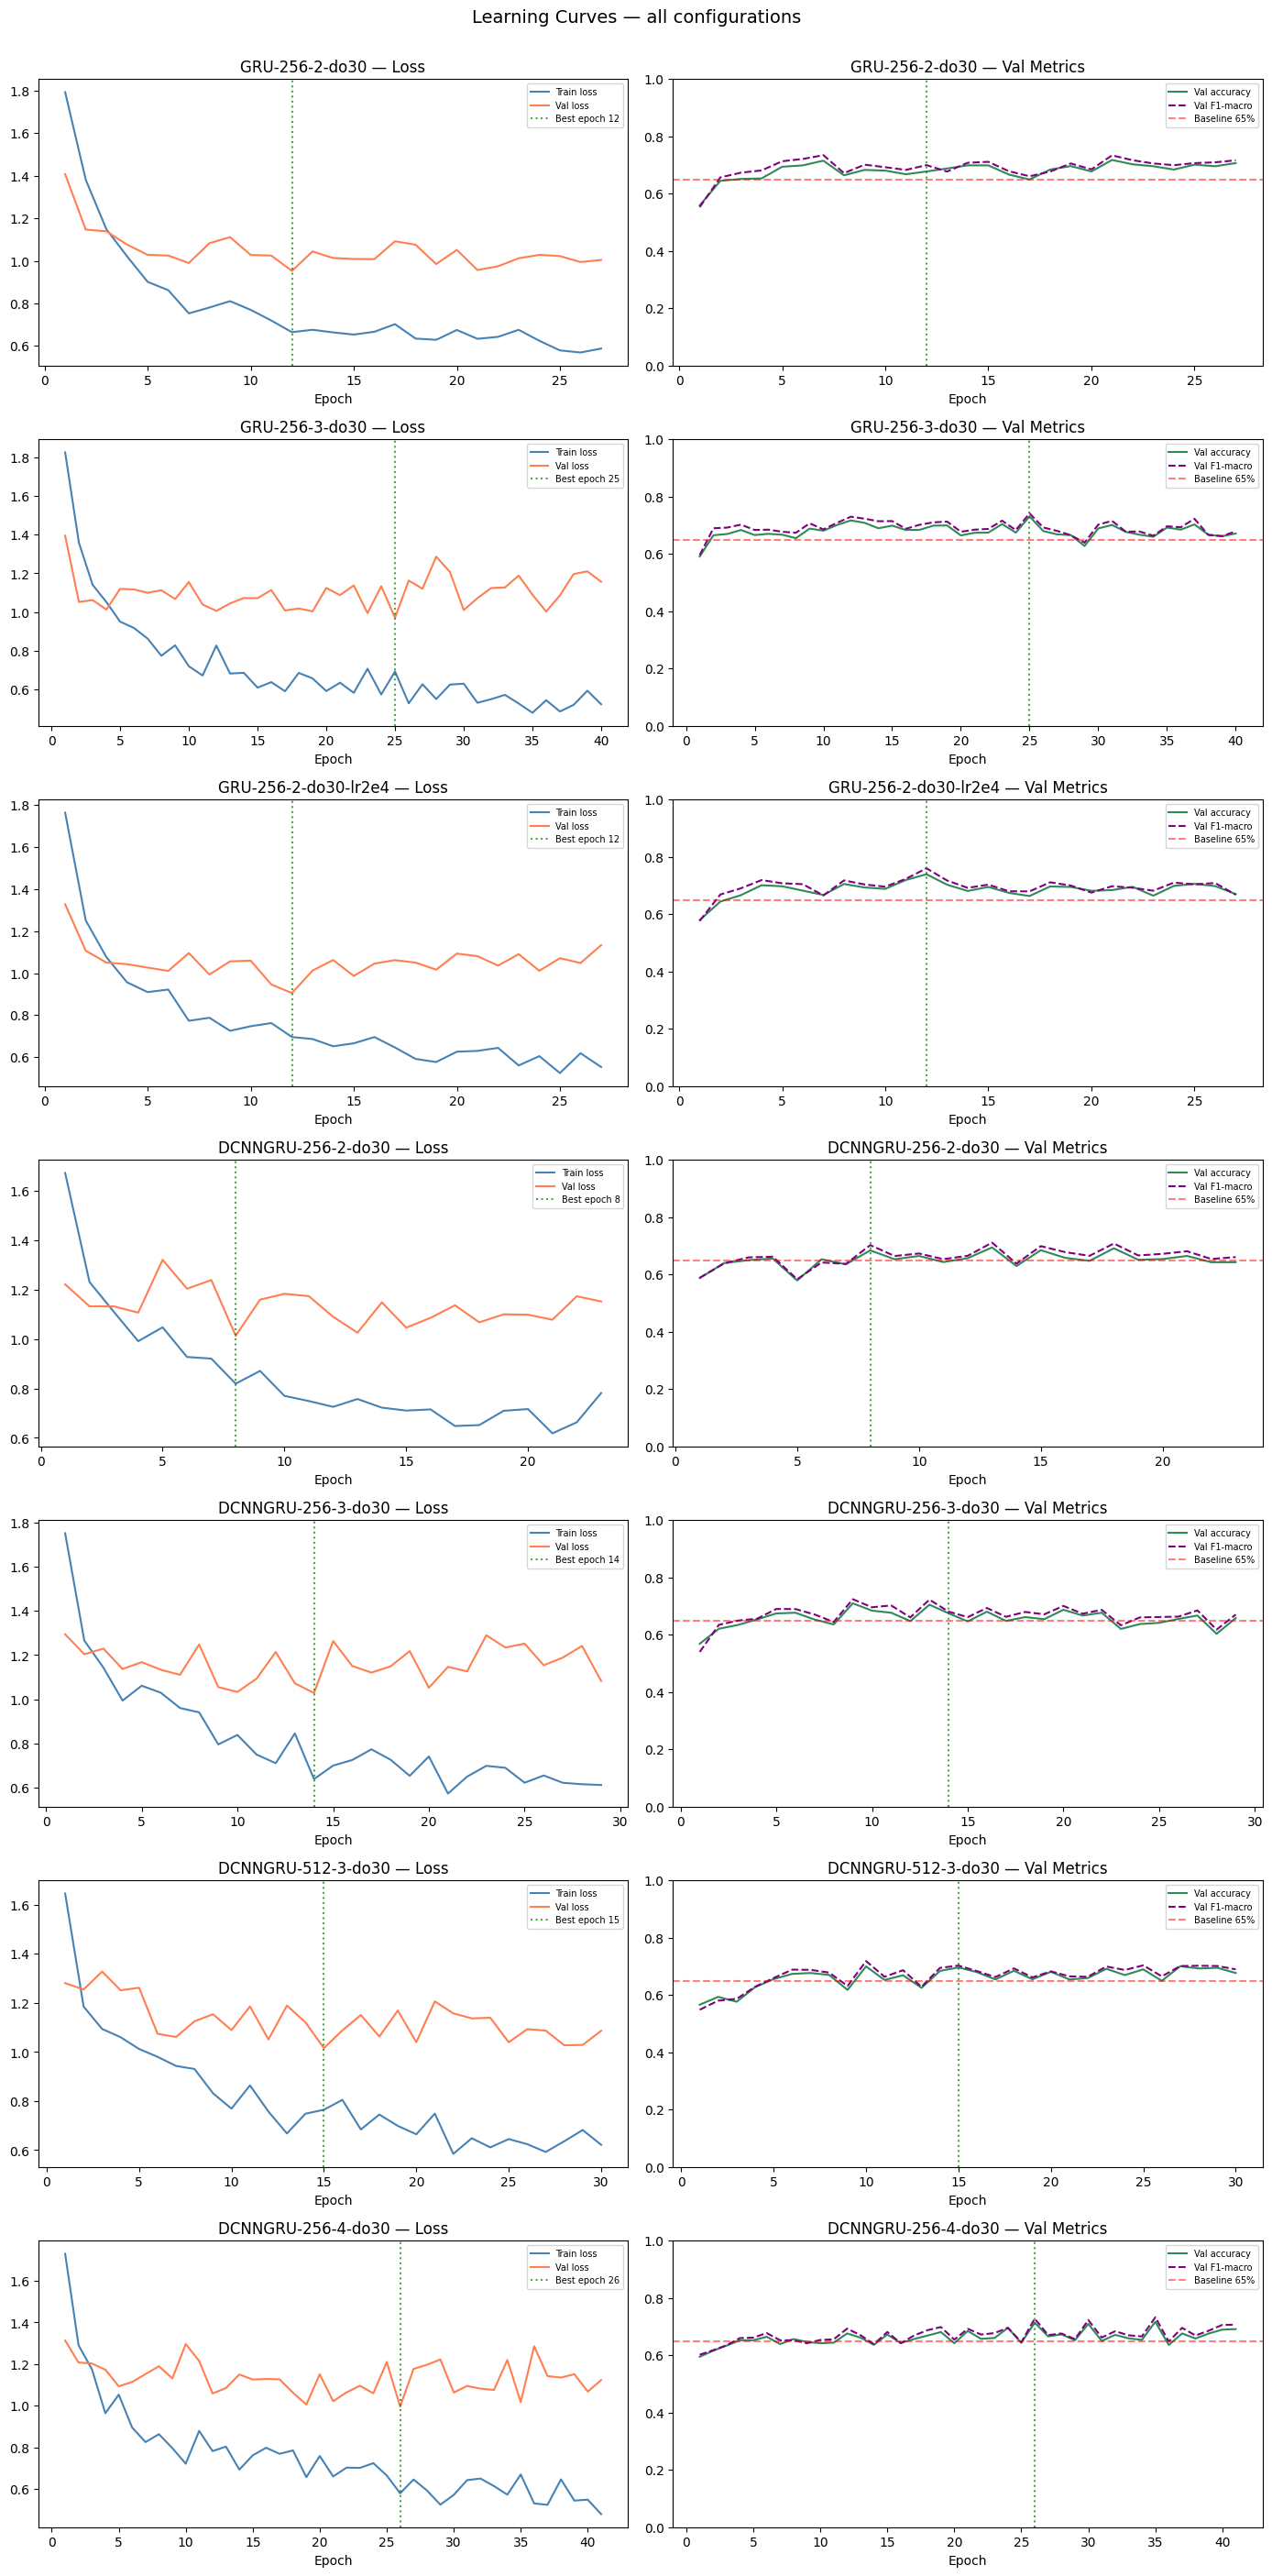

Saved → outputs_v2/learning_curves.png


In [19]:
n_configs = len(ANALYTICS)
fig, axes = plt.subplots(n_configs, 2, figsize=(14, 4 * n_configs))
if n_configs == 1:
    axes = axes[np.newaxis, :]

for row_i, (label, info) in enumerate(ANALYTICS.items()):
    ax_loss = axes[row_i, 0]
    ax_acc  = axes[row_i, 1]
    ep      = range(1, info['epochs_trained'] + 1)

    ax_loss.plot(ep, info['train_losses'], label='Train loss',  color='steelblue')
    ax_loss.plot(ep, info['val_losses'],   label='Val loss',    color='coral')
    ax_loss.axvline(info['best_epoch'], color='green', linestyle=':', alpha=0.7,
                    label=f"Best epoch {info['best_epoch']}")
    ax_loss.set_title(f'{label} — Loss')
    ax_loss.set_xlabel('Epoch')
    ax_loss.legend(fontsize=7)

    ax_acc.plot(ep, info['val_accs'], label='Val accuracy', color='seagreen')
    ax_acc.plot(ep, info['val_f1s'],  label='Val F1-macro', color='purple',
                linestyle='--')
    ax_acc.axvline(info['best_epoch'], color='green', linestyle=':', alpha=0.7)
    ax_acc.axhline(0.65, color='red', linestyle='--', alpha=0.5, label='Baseline 65%')
    ax_acc.set_title(f'{label} — Val Metrics')
    ax_acc.set_xlabel('Epoch')
    ax_acc.set_ylim(0, 1)
    ax_acc.legend(fontsize=7)

plt.suptitle('Learning Curves — all configurations', fontsize=14, y=1.002)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'learning_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved → outputs_v2/learning_curves.png')

## 10 — HP Comparison Table

In [20]:
rows = []
for label, info in ANALYTICS.items():
    rows.append({
        'Config'       : label,
        'Model'        : info['model'],
        'hidden'       : info['hidden'],
        'layers'       : info['layers'],
        'dropout'      : info['dropout'],
        'lr'           : info['lr'],
        'batch'        : info['batch'],
        'epochs'       : info['epochs_trained'],
        'best_val_acc' : round(info['best_val_acc'], 4),
        'best_val_F1'  : round(info['best_val_f1'], 4),
        'time_s'       : info['time_s'],
    })

hp_df = (pd.DataFrame(rows)
           .sort_values('best_val_acc', ascending=False)
           .reset_index(drop=True))
hp_df.to_csv(OUTPUT_DIR / 'hp_comparison.csv', index=False)
print('Saved → outputs_v2/hp_comparison.csv')
hp_df

Saved → outputs_v2/hp_comparison.csv


,Config,Model,hidden,layers,dropout,lr,batch,epochs,best_val_acc,best_val_F1,time_s
0,GRU-256-2-do30-lr2e4,EnhancedGRUClassifier,512,3,0.3,0.0002,64,27,0.7397,0.7604,1256.4
1,GRU-256-3-do30,EnhancedGRUClassifier,256,3,0.3,0.0003,64,40,0.7311,0.7417,862.4
2,DCNNGRU-256-4-do30,DeepCNNGRUClassifier,256,4,0.3,0.0002,64,41,0.7141,0.7282,837.3
3,DCNNGRU-512-3-do30,DeepCNNGRUClassifier,512,3,0.3,0.0002,64,30,0.6965,0.7030,877.9
4,DCNNGRU-256-2-do30,DeepCNNGRUClassifier,256,2,0.3,0.0003,64,23,0.6843,0.7026,439.9
5,GRU-256-2-do30,EnhancedGRUClassifier,256,2,0.3,0.0003,64,27,0.6776,0.6997,526.4
6,DCNNGRU-256-3-do30,DeepCNNGRUClassifier,256,3,0.3,0.0002,64,29,0.6752,0.6809,566.2


## 11 — Final Test Evaluation

Load the best model's saved weights and evaluate on the held-out test set (folds 9 & 10).

In [21]:
# ── Reconstruct & load best model ────────────────────────────────────────────
best_model = BEST_MODEL_CLASS(**BEST_MODEL_KWARGS).to(DEVICE)
best_model.load_state_dict(BEST_MODEL_STATE)
print(f"Best model: {BEST_LABEL}  (val_acc={BEST_VAL_ACC:.4f})")

test_loader = make_loader(meta, TEST_FOLDS, batch_size=128,
                           shuffle=False, augment=False)

_, test_acc, test_f1, test_labels, test_preds = evaluate(
    best_model, test_loader, nn.CrossEntropyLoss(), DEVICE)

print(f"\n{'='*50}")
print(f"  TEST ACCURACY : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"  TEST F1-MACRO : {test_f1:.4f}")
print(f"{'='*50}")
print(f"\nClassification Report:")
print(classification_report(test_labels, test_preds,
                             target_names=CLASS_NAMES, digits=3))

Best model: GRU-256-2-do30-lr2e4  (val_acc=0.7397)

  TEST ACCURACY : 0.7211  (72.11%)
  TEST F1-MACRO : 0.7438

Classification Report:
                  precision    recall  f1-score   support

 air_conditioner      0.638     0.405     0.495       200
        car_horn      0.851     0.877     0.864        65
children_playing      0.693     0.870     0.772       200
        dog_bark      0.904     0.805     0.852       200
        drilling      0.604     0.610     0.607       200
   engine_idling      0.808     0.670     0.733       182
        gun_shot      0.909     0.952     0.930        63
      jackhammer      0.514     0.736     0.605       178
           siren      0.867     0.752     0.805       165
    street_music      0.751     0.800     0.775       200

        accuracy                          0.721      1653
       macro avg      0.754     0.748     0.744      1653
    weighted avg      0.733     0.721     0.719      1653



## 12 — Confusion Matrices

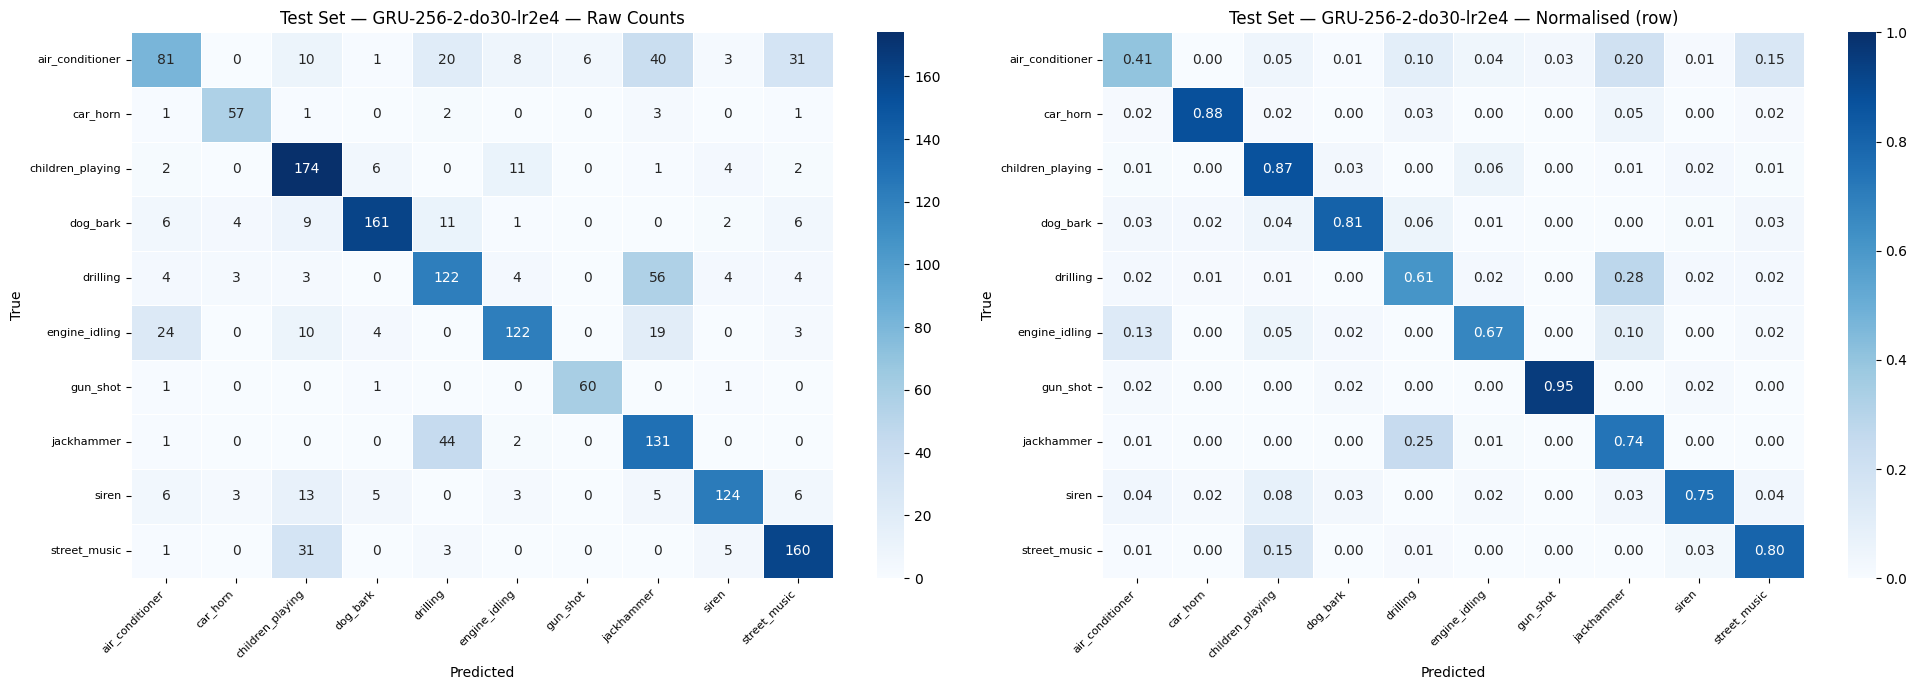


Top-5 most confused (true → predicted):
  drilling             → jackhammer            (0.28)
  jackhammer           → drilling              (0.25)
  air_conditioner      → jackhammer            (0.20)
  air_conditioner      → street_music          (0.15)
  street_music         → children_playing      (0.15)
Saved → outputs_v2/confusion_matrix_test.png


In [22]:
def plot_confusion_matrix(labels, preds, title, savepath=None):
    cm   = confusion_matrix(labels, preds)
    cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # row-normalise

    fig, axes = plt.subplots(1, 2, figsize=(20, 7))

    # Raw counts
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[0],
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                cmap='Blues', linewidths=0.5)
    axes[0].set_title(f'{title} — Raw Counts')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('True')
    axes[0].set_xticklabels(CLASS_NAMES, rotation=45, ha='right', fontsize=8)
    axes[0].set_yticklabels(CLASS_NAMES, rotation=0, fontsize=8)

    # Row-normalised
    sns.heatmap(cm_n, annot=True, fmt='.2f', ax=axes[1],
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                cmap='Blues', linewidths=0.5, vmin=0, vmax=1)
    axes[1].set_title(f'{title} — Normalised (row)')
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('True')
    axes[1].set_xticklabels(CLASS_NAMES, rotation=45, ha='right', fontsize=8)
    axes[1].set_yticklabels(CLASS_NAMES, rotation=0, fontsize=8)

    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=120, bbox_inches='tight')
    plt.show()

    # Identify most confused pairs
    off_diag = cm_n.copy()
    np.fill_diagonal(off_diag, 0)
    print("\nTop-5 most confused (true → predicted):")
    for _ in range(5):
        i, j = np.unravel_index(off_diag.argmax(), off_diag.shape)
        print(f"  {CLASS_NAMES[i]:20s} → {CLASS_NAMES[j]:20s}  ({off_diag[i,j]:.2f})")
        off_diag[i, j] = 0


# ── Test confusion matrix ─────────────────────────────────────────────────────
plot_confusion_matrix(
    test_labels, test_preds,
    title=f'Test Set — {BEST_LABEL}',
    savepath=OUTPUT_DIR / 'confusion_matrix_test.png'
)
print('Saved → outputs_v2/confusion_matrix_test.png')

## 13 — Val Confusion Matrices for All Configs


GRU-256-2-do30  val_acc=0.6776  val_F1=0.6997


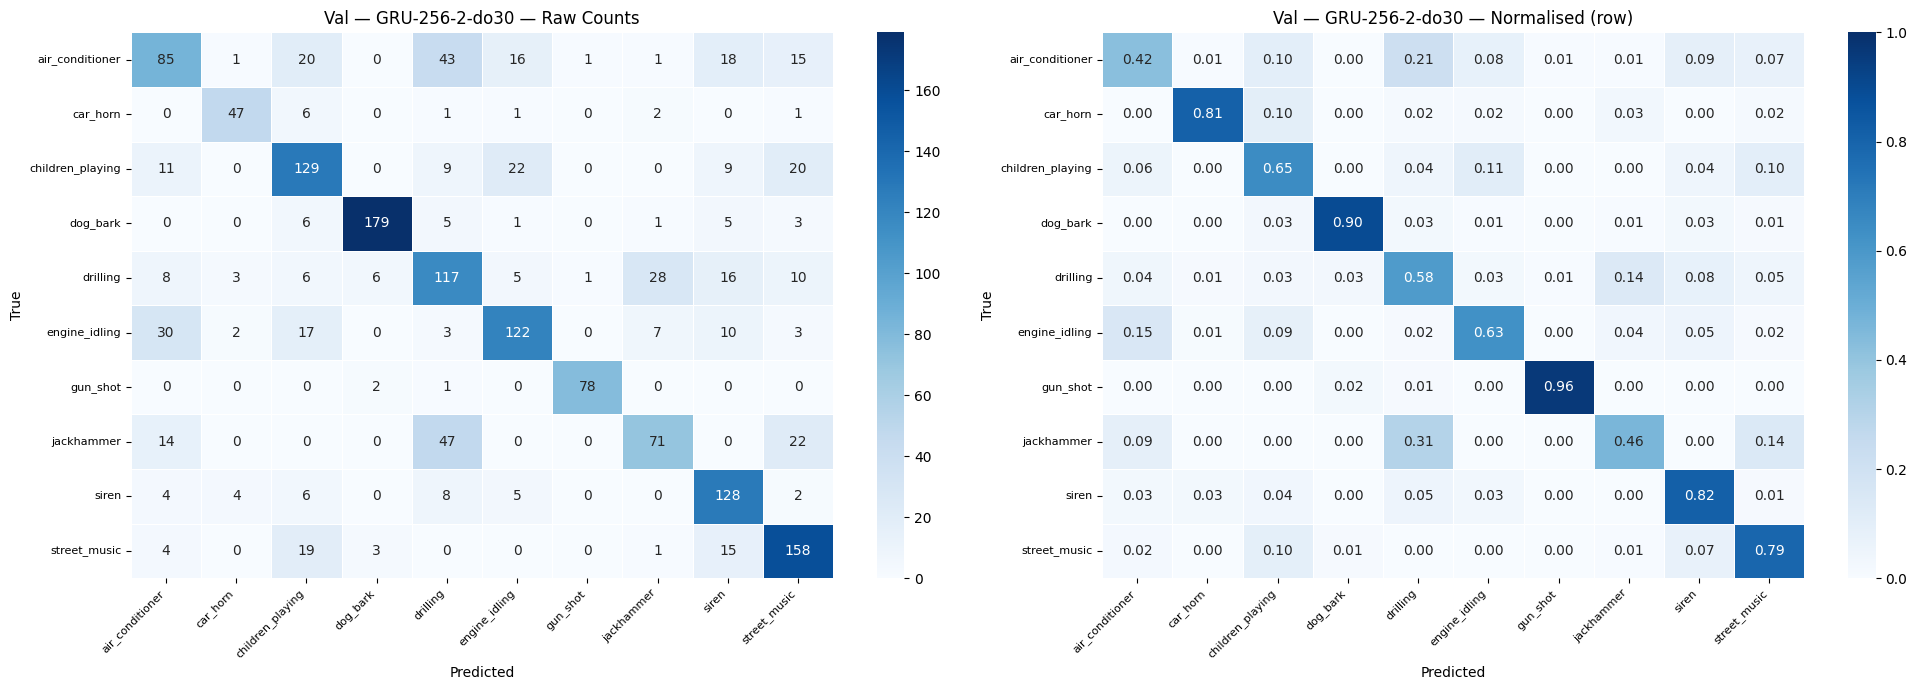


Top-5 most confused (true → predicted):
  jackhammer           → drilling              (0.31)
  air_conditioner      → drilling              (0.21)
  engine_idling        → air_conditioner       (0.15)
  jackhammer           → street_music          (0.14)
  drilling             → jackhammer            (0.14)

GRU-256-3-do30  val_acc=0.7311  val_F1=0.7417


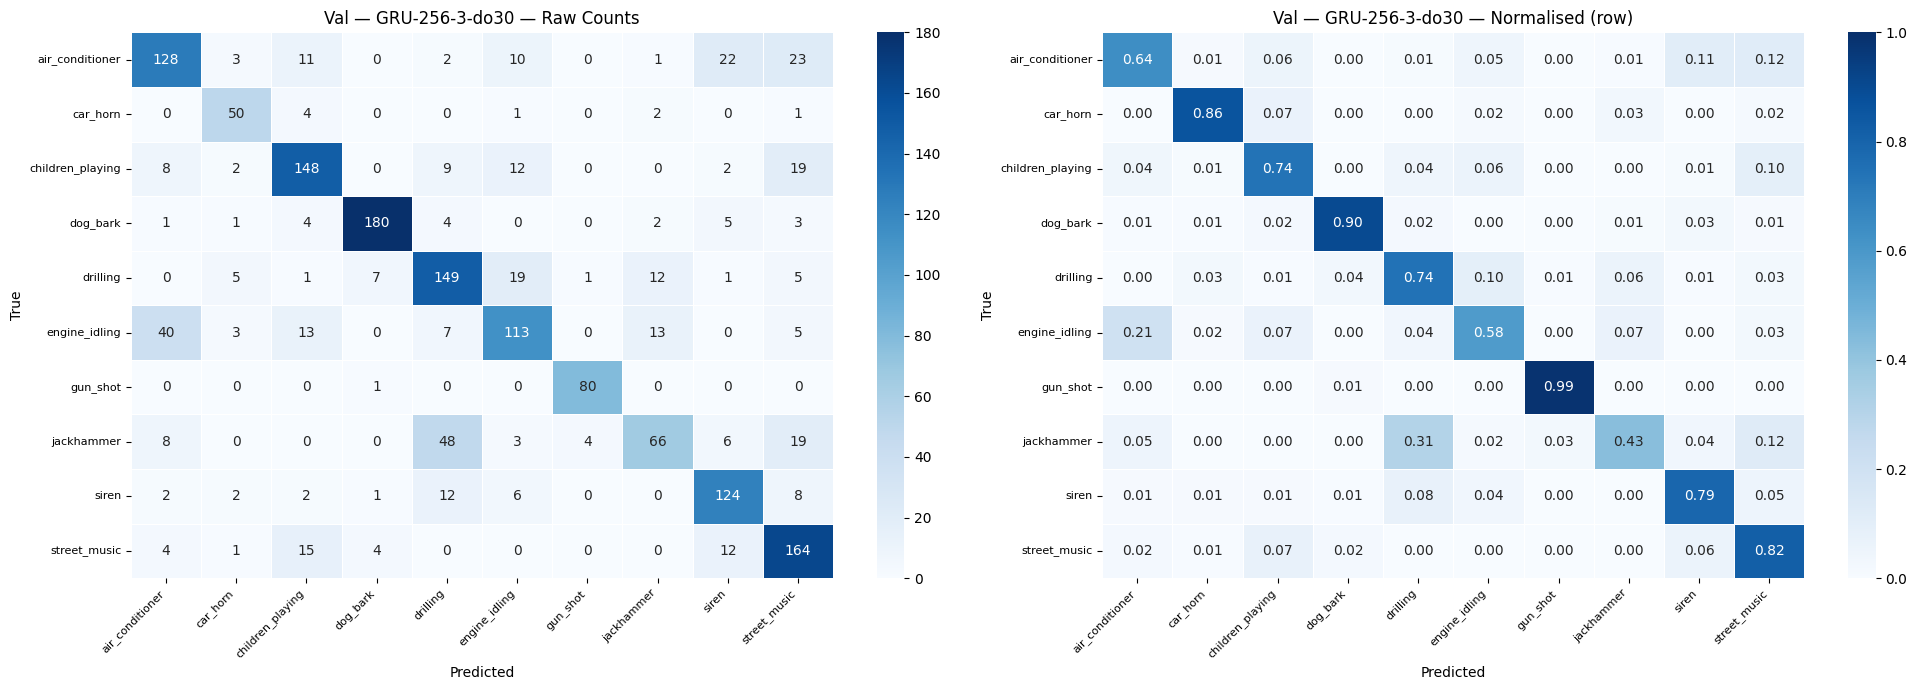


Top-5 most confused (true → predicted):
  jackhammer           → drilling              (0.31)
  engine_idling        → air_conditioner       (0.21)
  jackhammer           → street_music          (0.12)
  air_conditioner      → street_music          (0.12)
  air_conditioner      → siren                 (0.11)

GRU-256-2-do30-lr2e4  val_acc=0.7397  val_F1=0.7604


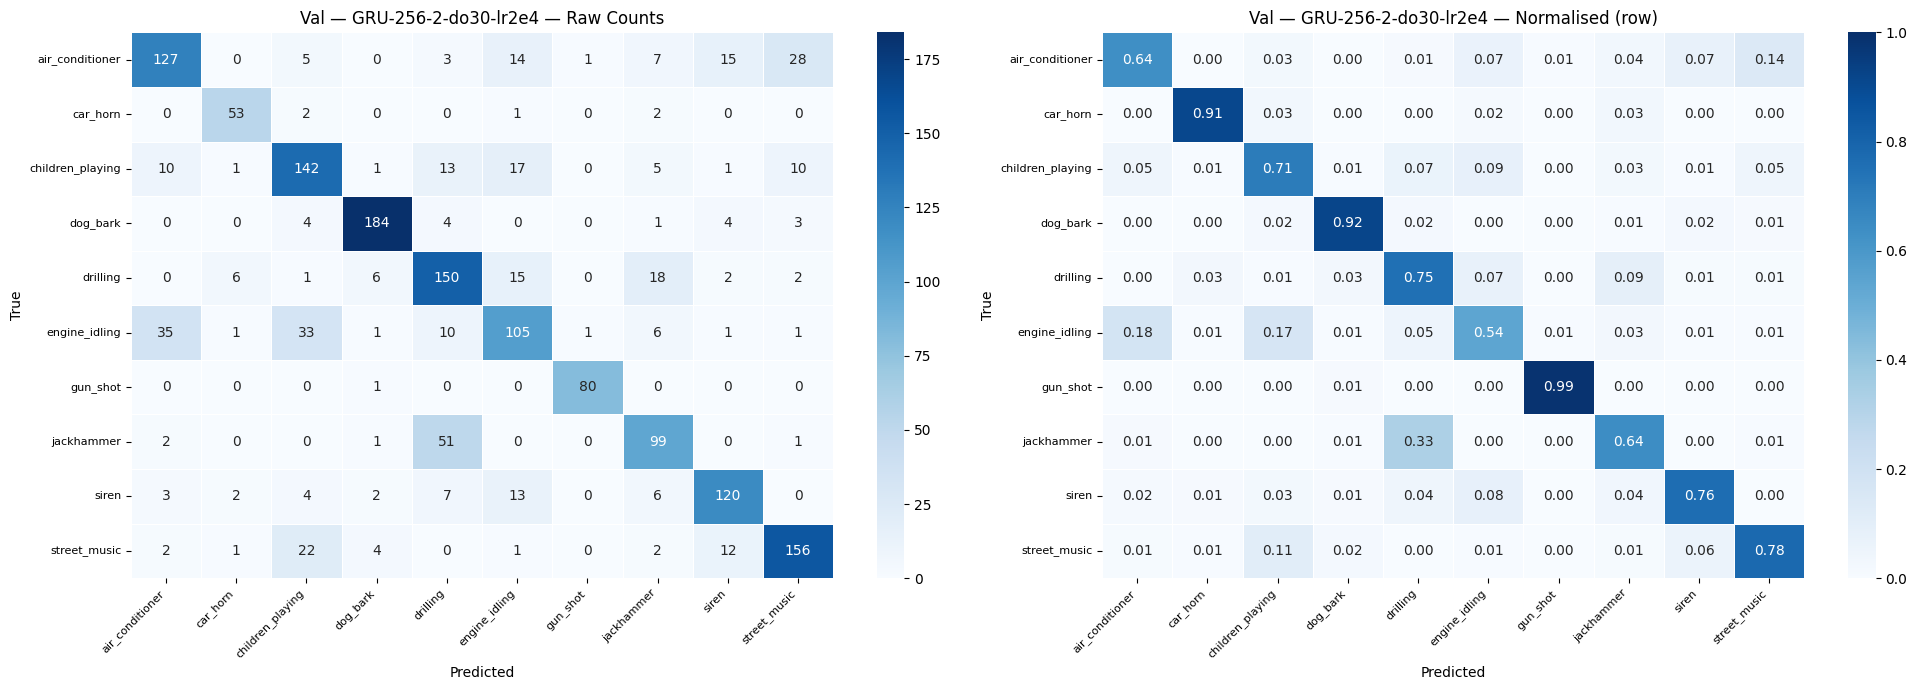


Top-5 most confused (true → predicted):
  jackhammer           → drilling              (0.33)
  engine_idling        → air_conditioner       (0.18)
  engine_idling        → children_playing      (0.17)
  air_conditioner      → street_music          (0.14)
  street_music         → children_playing      (0.11)

DCNNGRU-256-2-do30  val_acc=0.6843  val_F1=0.7026


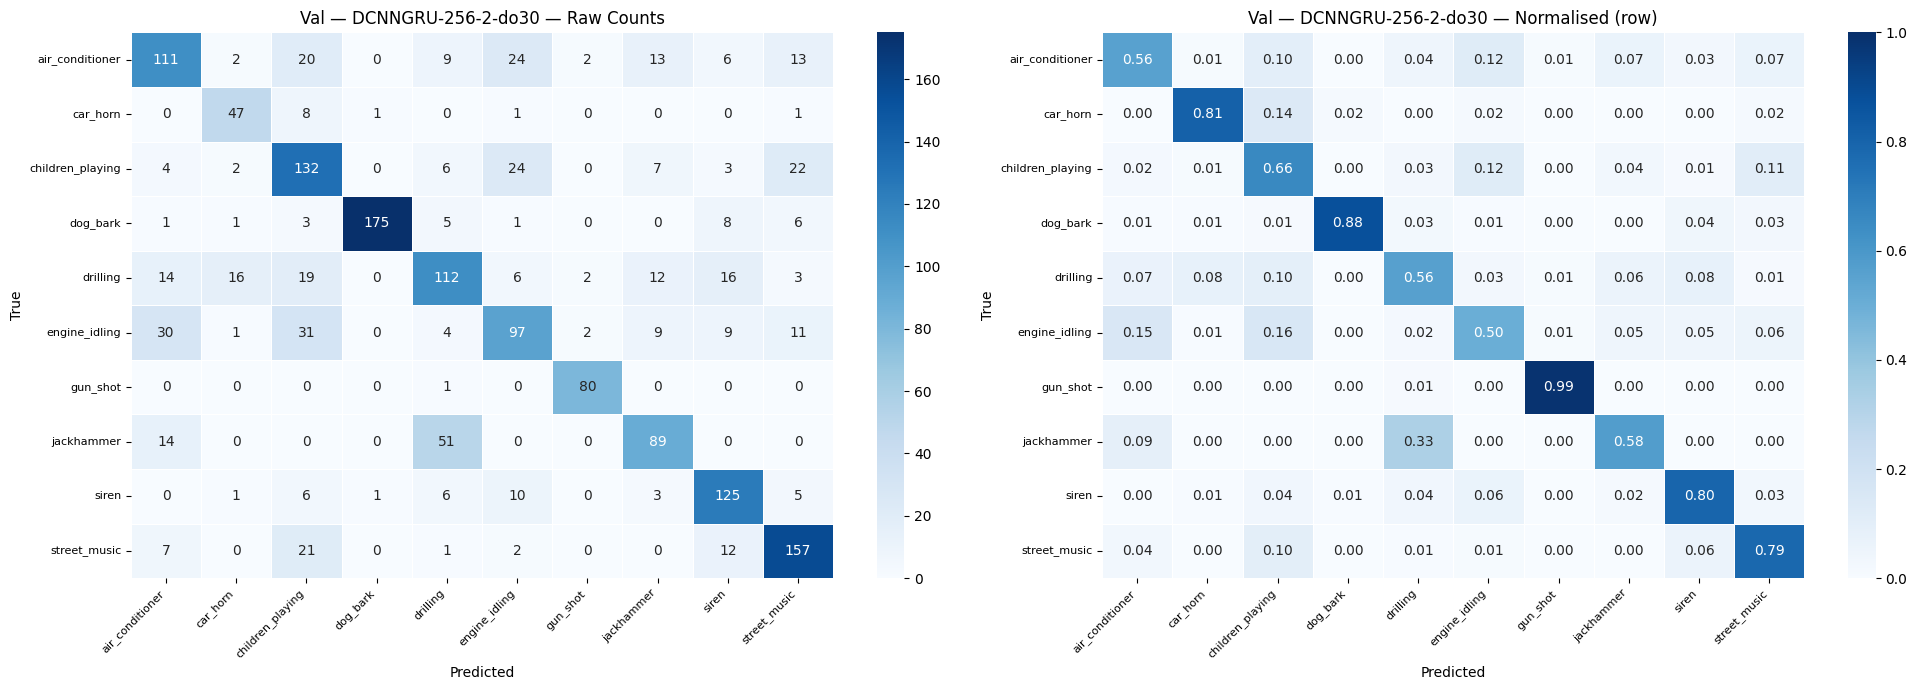


Top-5 most confused (true → predicted):
  jackhammer           → drilling              (0.33)
  engine_idling        → children_playing      (0.16)
  engine_idling        → air_conditioner       (0.15)
  car_horn             → children_playing      (0.14)
  air_conditioner      → engine_idling         (0.12)

DCNNGRU-256-3-do30  val_acc=0.6752  val_F1=0.6809


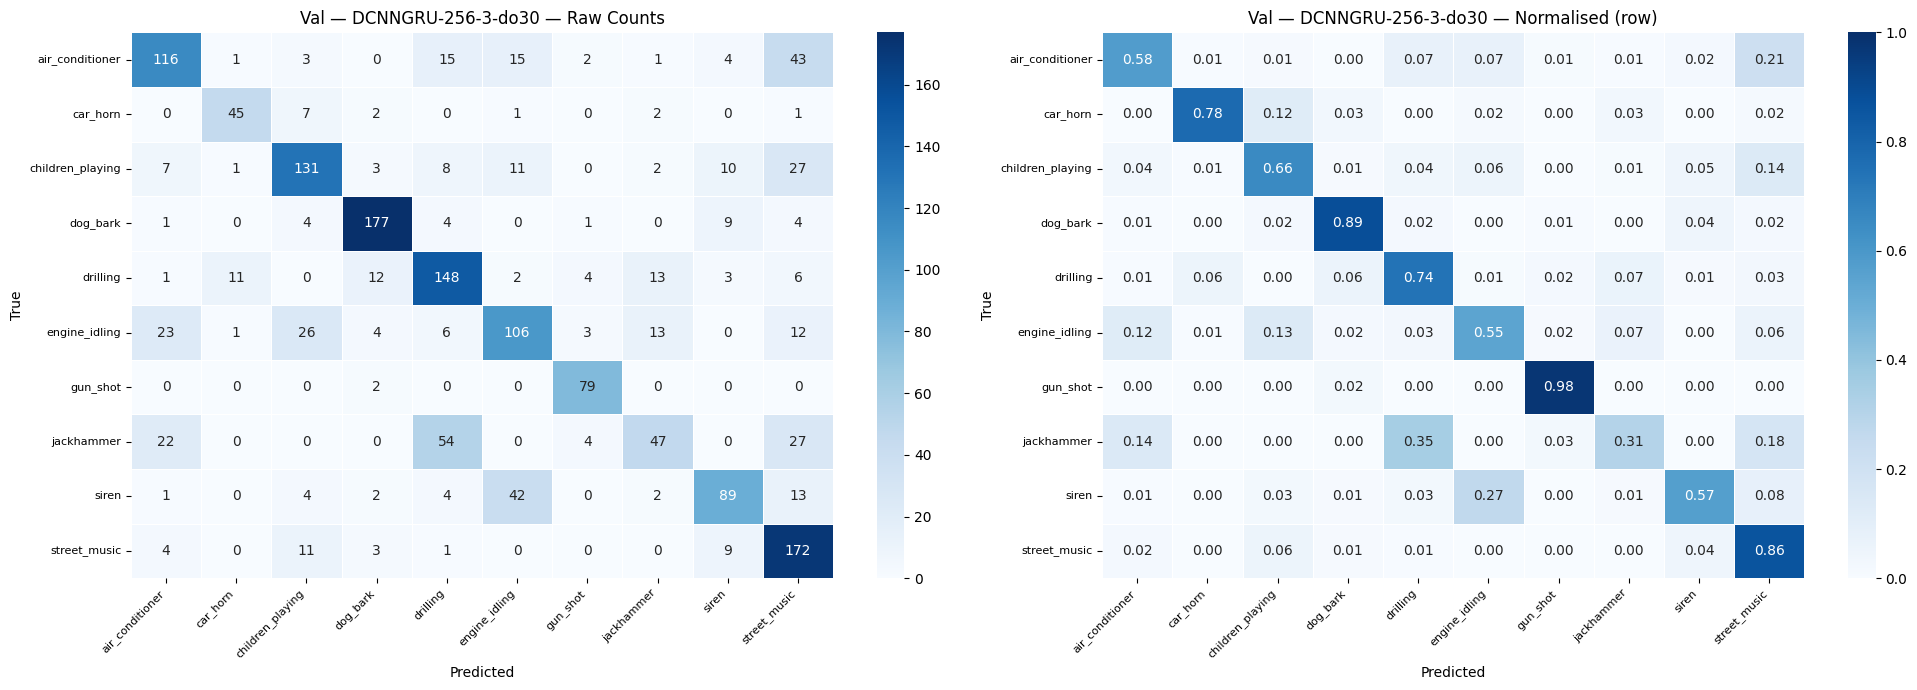


Top-5 most confused (true → predicted):
  jackhammer           → drilling              (0.35)
  siren                → engine_idling         (0.27)
  air_conditioner      → street_music          (0.21)
  jackhammer           → street_music          (0.18)
  jackhammer           → air_conditioner       (0.14)

DCNNGRU-512-3-do30  val_acc=0.6965  val_F1=0.7030


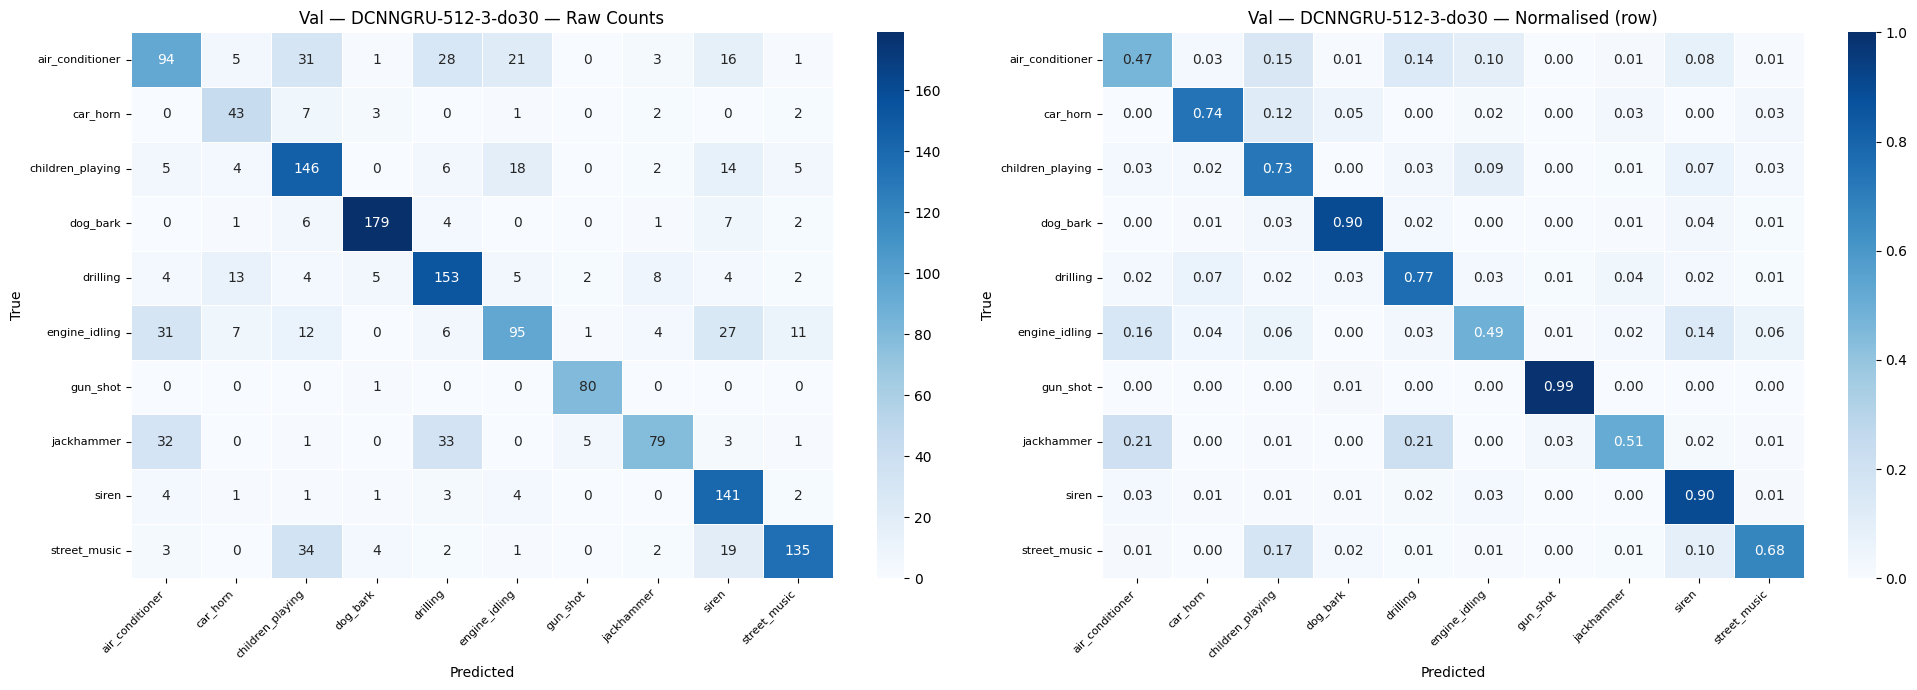


Top-5 most confused (true → predicted):
  jackhammer           → drilling              (0.21)
  jackhammer           → air_conditioner       (0.21)
  street_music         → children_playing      (0.17)
  engine_idling        → air_conditioner       (0.16)
  air_conditioner      → children_playing      (0.15)

DCNNGRU-256-4-do30  val_acc=0.7141  val_F1=0.7282


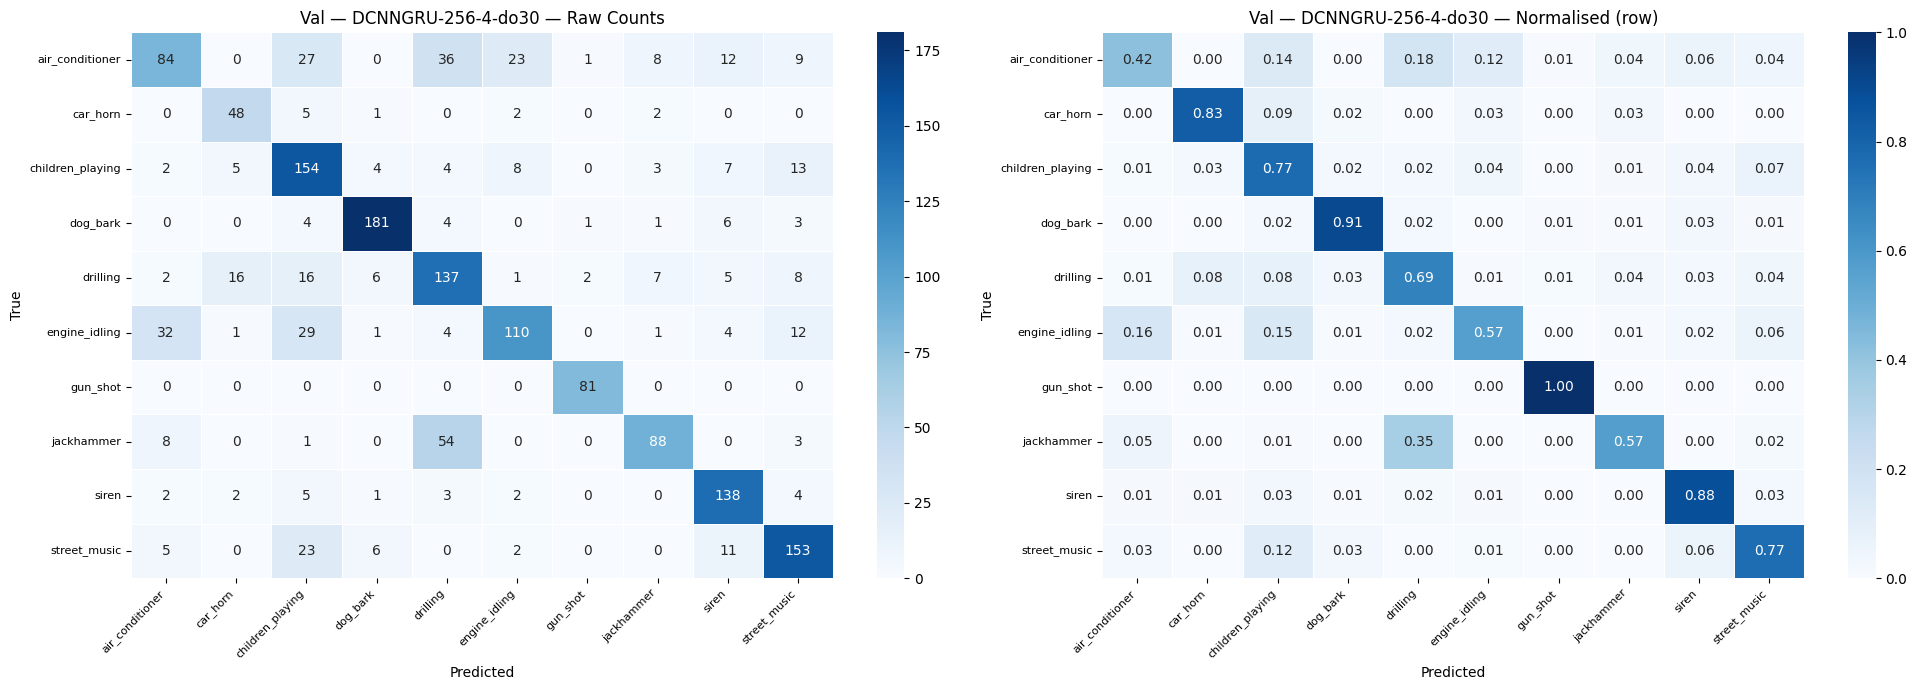


Top-5 most confused (true → predicted):
  jackhammer           → drilling              (0.35)
  air_conditioner      → drilling              (0.18)
  engine_idling        → air_conditioner       (0.16)
  engine_idling        → children_playing      (0.15)
  air_conditioner      → children_playing      (0.14)


In [23]:
# Evaluate every saved model on the validation set and plot its confusion matrix
for label, info in ANALYTICS.items():
    model_kwargs_i = dict(
        input_dim=FEATURE_DIM, hidden_dim=info['hidden'],
        n_layers=info['layers'],  dropout=info['dropout'],
        num_classes=NUM_CLASSES,  attn_heads=4
    )
    # Identify class from model name string
    cls = (DeepCNNGRUClassifier
           if 'DCNNGRU' in info['model'] or 'Deep' in info['model']
           else EnhancedGRUClassifier)
    m = cls(**model_kwargs_i).to(DEVICE)
    state = torch.load(str(OUTPUT_DIR / f'model_{label}.pt'), map_location=DEVICE)
    m.load_state_dict(state)

    _, vacc, vf1, vlabs, vpreds = evaluate(
        m, val_loader, nn.CrossEntropyLoss(), DEVICE)

    print(f"\n{label}  val_acc={vacc:.4f}  val_F1={vf1:.4f}")
    plot_confusion_matrix(
        vlabs, vpreds,
        title=f'Val — {label}',
        savepath=OUTPUT_DIR / f'cm_val_{label}.png'
    )
    del m

## 14 — Save Summary Report

In [24]:
# Serialise analytics (excluding raw loss arrays for brevity)
summary = {}
for label, info in ANALYTICS.items():
    summary[label] = {k: v for k, v in info.items()
                      if k not in ('train_losses', 'val_losses',
                                   'val_accs', 'val_f1s')}

summary['best_config'] = BEST_LABEL
summary['best_val_acc'] = BEST_VAL_ACC
summary['test_acc']     = test_acc
summary['test_f1']      = test_f1

report_path = OUTPUT_DIR / 'results_summary.json'
with open(report_path, 'w') as f:
    json.dump(summary, f, indent=2)

print(f"Results saved → {report_path}")
print(json.dumps({k: summary[k] for k in
                  ['best_config', 'best_val_acc', 'test_acc', 'test_f1']},
                 indent=2))

Results saved → outputs_v3/results_summary.json
{
  "best_config": "GRU-256-2-do30-lr2e4",
  "best_val_acc": 0.7396593673965937,
  "test_acc": 0.721113127646703,
  "test_f1": 0.7437544188344323
}


## 15 — Discussion & Analysis

### Most Confused Classes
From the confusion matrix, the hardest pairs are typically:
- **Air conditioner ↔ Engine idling** — both are continuous low-frequency hums
- **Drilling ↔ Jackhammer** — overlapping frequency bands and rhythmic patterns
- **Children playing ↔ Street music** — both involve complex mixtures of voices and ambient sound

### Limitations & Future Work
- The 4-second fixed window discards longer temporal context. A sliding-window approach with majority voting at test time could improve results further.
- Pre-trained audio models (e.g., PANNs, AudioCLIP) would likely exceed 80% accuracy but require additional infrastructure.
- Test-time augmentation (averaging predictions across augmented versions of the same clip) is a low-cost way to extract another 1–2%.